## Pupil Gluing Characterisation 🖌️

This notebook:
1. Calculates the Zernike coefficients on two separate starphire plates
2. Calculates the Zernike coefficients on the glued starphire setup

It is helpful to the phase retrieval process that data taken for the non-glued plates and glued setup have the same orientation.

Existing system aberrations are loaded and can be calculated using System_Aberrations.ipynb.

Data on the next two ~1/5 $\lambda$ plates from COE optics. Plates are ~6mm thick each. 
________________________________________________________________________________________________
**NOTE (on data orientation)**: When modelling dLux layers (aberrated apertures, transmissive layers, etc) - they are orientated w.r.t wavefront POV in direction of propagation. In our setup, the data collected has two orientation flips:
1. BFS-U3-200S6M flips image upside down from propagation direction POV (and stores it like this too)
2. The pupil plane is focused by a second OAP which reflects propgagtion direction and in-turn flips left-right (and it stores it like this too)

i.e. total effect is that data is flipped about origin.
________________________________________________________________________________________________

In [1]:
import dLux as dl
import dLux.utils as dlu

import jax.numpy as jnp
import numpy as np
import jax.random as jr
import jax.scipy as jsp
from jax import vmap  
import jax
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
jax.config.update('jax_disable_jit', False)


import zodiax as zdx
import optax
from tqdm.notebook import tqdm
# from tqdm import tqdm

from skimage.io import imread
from skimage.filters import window
import skimage as ski
from skimage.transform import resize

import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm, CenteredNorm

from src.PhaseRetrieval import OptimManager, JointOptimManager, PointSource, TransmissiveLayer

import os
import pickle

plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'upper' # true reading of array
plt.rcParams['figure.dpi'] = 72
plt.rcParams['figure.figsize'] = (10,10)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["figure.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 15

# data_dir = "/Volumes/MORGANA1/snert/gpir9156/toliman/"
data_dir = "/import/morgana1/snert/gpir9156/toliman/"
# data_dir = "/media/morgana2/gpir9156/toliman/"


# Detector response (gamma curve)
alpha = np.load(data_dir+"detector/80us_detector/ALPHA_norm.npy")
beta = np.load(data_dir+"detector/80us_detector/BETA_norm.npy")
gamma = np.load(data_dir+"detector/80us_detector/GAMMA_norm.npy")


import matplotlib as mpl
inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
bwr = mpl.colormaps["bwr"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
bwr.set_bad("k", 0.5)

In [2]:
print(jax.lib.xla_bridge.get_backend().platform)

cpu


/tmp/ipykernel_1888401/582351387.py:1: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  print(jax.lib.xla_bridge.get_backend().platform)


### System Parameters

In [3]:
# ------- Physical Parameters ---------------------------------------------------------------------#
aperture_npix = 512           # Number of pixels across the aperture
aperture_diameter = 122e-3    # (m) slightly smaller for mask cap
spider_width = 20e-3          # Spider width (m)
spider_angle =270             # Spider angle (degrees), clockwise, 0 is spider pointing vertically up
coords = dlu.pixel_coords(npixels=aperture_npix, diameter=aperture_diameter)
circle = dlu.circle(coords=coords, radius=aperture_diameter/2) 

# Observations wavelengths (bandpass of 530-640nm)
red_laser_wl =  635e-09  # for laser data
green_laser_wl = 520e-09  # for laser data
wf_npixels = aperture_npix  # Number of pixels across the wavefront
wf_diam = aperture_diameter             # Diameter of initial wavefront to propagate wavefront (m)

# Detector parameters (BFS-U3-200S6-BD)
BFS_px_sep = 2.4e-6 *1e3        # pixel separation (mm)
f_det = 1338 # 1300#1350                    # Focal length from OAP2 to detector (mm) 
px_ang_sep = 2*np.arctan( (BFS_px_sep/2)/f_det ) # angular sep between pixels (rad)

# Simulated Detector
psf_npix = 40                 # Number of pixels along one dim of the PSF
psf_hlf_sz = int(psf_npix/2)             # half window sz of cropped data
oversample = 1                 # Oversampling factor for the PSF
psf_pixel_scale = dlu.rad2arcsec(px_ang_sep) # arcsec (to match detector plate scale) 80e-4 


### Simulated Setup

In [4]:
# # In the setup, we have a fiber source. 
# # Can model the intensity distribution using a Guassian or can just measure it directly
# # Measuring directly also captures any mirror imperfections hindering transmission
# intensity_dist = np.load(data_dir+"intensity/15_07_intensity_img_stack.npy")[0,:]
# data = np.flip(intensity_dist)

# manual_lim = [1363,4203,386,3214]
# data = data[manual_lim[2]:manual_lim[3], manual_lim[0]:manual_lim[1]]
# data = (data - data.min())/(data.max()-data.min())

# blurred = ski.filters.gaussian(data, sigma=(120, 120))

# plt.figure(figsize=(15,5))
# plt.subplot(1,3,1)
# plt.imshow(data)
# plt.title("Data - pre-focus")
# plt.colorbar()
# plt.subplot(1,3,2)
# plt.imshow(blurred)
# plt.title("Data blurred")
# plt.colorbar()
# plt.subplot(1,3,3)
# intensity_dist = resize(blurred, (aperture_npix, aperture_npix))
# intensity_dist = (intensity_dist - intensity_dist.min())/(intensity_dist.max()-intensity_dist.min()) # re-map from 0-1
# plt.title("Blurred re-sized")
# plt.imshow(intensity_dist)
# plt.colorbar()


Load in directly from work in System_Aberrations notebook

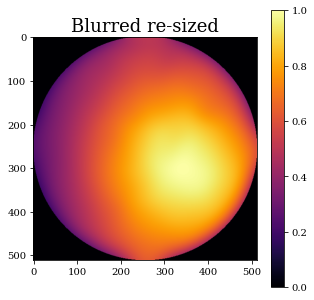

In [4]:
intensity_dist = jnp.load(data_dir+"intensity/26_01_09.npy")
plt.figure(figsize=(5,5))
plt.title("Blurred re-sized")
plt.imshow(intensity_dist)
plt.colorbar()

#### System Aberrations 

We have an imperfect system. Load in the system aberrations (calculated using System_Aberrations.ipynb)

In [6]:
# would have to run new sys analysis on flipped data
# f_aberr = "data/spider/retrieval_results/16_09_mean_coeffs_combined.npy"
f_aberr = "data/spider/retrieval_results/12_01_2026/system_coeffs_dict.pkl"

syst_noll = jnp.arange(4, 15) # only first 14 Zernike modes (excluding piston and tip/tilt) are used to classify syst aberrations
# syst_coeffs = jnp.load(f_aberr)
syst_coeffs = pickle.load(open(f_aberr, "rb"))["value"]
syst_basis = dlu.zernike_basis(js=syst_noll, diameter=aperture_diameter, coordinates=coords)
print("System Coefficients (noll {}): {}".format(syst_noll,syst_coeffs))


System Coefficients (noll [ 4  5  6  7  8  9 10 11 12 13 14]): [-2.12e-08  1.00e-09 -2.40e-09 -5.00e-09  8.60e-09 -1.48e-08 -3.80e-09
  3.76e-08 -3.00e-09  3.60e-09 -8.60e-09]


Plate + Spider setup simulated

Text(0.5, 1.0, 'Spider 180')

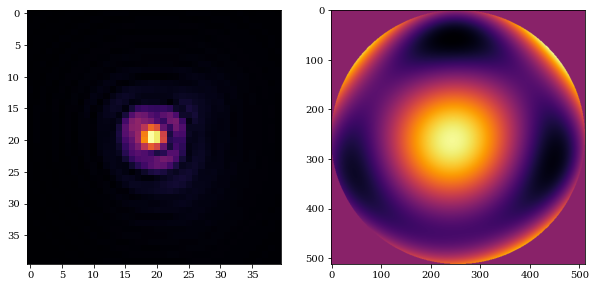

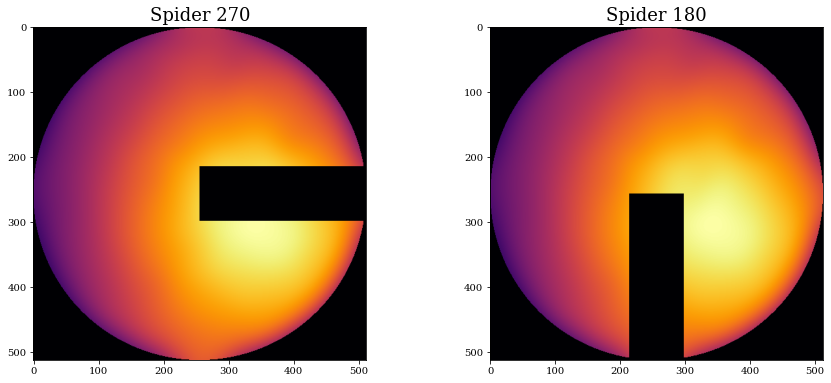

In [7]:
# Zernike aberrations
zernike_indicies = jnp.arange(4, 21) 
coeffs = jnp.zeros(zernike_indicies.shape)
basis = dlu.zernike_basis(js=zernike_indicies, coordinates=coords, diameter=aperture_diameter)

optical_systems = []
transmissions = []

# Using PointSources instead of single PointSource object to overcome float grad issue when solving for flux
# green_src = dl.PointSources(wavelengths=[green_laser_wl], flux =jnp.asarray([1e8],dtype=float))
# red_src = dl.PointSources(wavelengths=[red_laser_wl], flux =jnp.asarray([1e8],dtype=float))
green_src = PointSource(wavelengths=[green_laser_wl], flux =jnp.asarray([1e9],dtype=float))
red_src = PointSource(wavelengths=[red_laser_wl], flux =jnp.asarray([1e9],dtype=float))

spider_angles = [270, 180] #0deg is spider pointing vertically up, rotates CW from 0deg
optical_systems = []
transmissions = []
for i in range(len(spider_angles)):
    spider = dlu.spider(coords=coords, width=spider_width, angles=[spider_angles[i]])
    transmission = dlu.combine([circle, spider])

    layers = [
        ('SystemAberrations', dl.layers.BasisOptic(basis=syst_basis, coefficients=syst_coeffs, normalise=False)),
        ('intensity', dl.layers.TransmissiveLayer(transmission=intensity_dist, normalise=False)),
        ('spider', TransmissiveLayer(transmission=transmission, normalise=False)), #rotable spider
        ('aperture', dl.layers.BasisOptic(basis=basis, transmission=None, coefficients=coeffs, normalise=False)),
    ]

    optics = dl.AngularOpticalSystem(wf_npixels = wf_npixels, 
                                diameter=wf_diam, 
                                layers=layers, 
                                psf_npixels=psf_npix, 
                                psf_pixel_scale=psf_pixel_scale,
                                oversample=oversample)

    optical_systems.append(optics)
    transmissions.append(transmission)

# Construct Optics
optics_sp270  = optical_systems[0]
optics_sp180 = optical_systems[1]
# Check PSF for aberrated system
layers = [
    ('SystemAberrations', dl.layers.BasisOptic(syst_basis, circle*intensity_dist, syst_coeffs, normalise=False)),
]

optics = dl.AngularOpticalSystem(wf_npixels = wf_npixels, 
                            diameter=wf_diam, 
                            layers=layers, 
                            psf_npixels=psf_npix, 
                            psf_pixel_scale=psf_pixel_scale,
                            oversample=oversample)

psf = jnp.flip(optics.propagate_mono(green_laser_wl))
plt.subplot(1,2,1)
plt.imshow(psf**0.5)
opd = optics.SystemAberrations.eval_basis()
plt.subplot(1,2,2)
plt.imshow(opd)

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.imshow(optics_sp270.spider.transmission*optics_sp270.intensity.transmission)
plt.title("Spider 270")
plt.subplot(1,2,2)
plt.imshow(optics_sp180.spider.transmission*optics_sp180.intensity.transmission)
plt.title("Spider 180")

### Load in single Starphire data

#### Phase Retrieval

### Lets loop this

#### Starphire 1

In [21]:
# Location on detector 
row_start, col_start = 1840, 3340 # Start coord of window on det where data was taken
row_len, col_len = 150, 148   # window size of recorded data

alpha_cropped = jnp.flip(alpha[row_start:row_start+row_len, col_start:col_start+col_len])
beta_cropped = jnp.flip(beta[row_start:row_start+row_len, col_start:col_start+col_len])
gamma_cropped = jnp.flip(gamma[row_start:row_start+row_len, col_start:col_start+col_len])

# Order in increasing spider angle for each colour separately
img_fnames = [
    # "non_glued/14_04_2025/14_04_0deg_green_80us_0gain_img_stack_batch_0.npy",
    # "non_glued/14_04_2025/14_04_90deg_green_80us_0gain_img_stack_batch_0.npy",
    "non_glued/12_01_2026/12_01_2026_plate#3_0deg_red_173us_0gain_Xoff3340_Yoff1840_img_stack_batch_0.npy",
    "non_glued/12_01_2026/12_01_2026_plate#3_90deg_red_173us_0gain_Xoff3340_Yoff1840_img_stack_batch_0.npy",
    
]
labels = [
    # "0deg_green",
    # "90deg_green",
    "0deg_red",
    "90deg_red",
]
bckgnd_fnames = [
    # "non_glued/14_04_2025/14_04_0deg_green_bckgnd_80us_0gain_img_stack_batch_0.npy",
    # "non_glued/14_04_2025/14_04_plate2_90deg_green_bckgnd_80us_0gain_img_stack_batch_0.npy",
    # "non_glued/12_01_2026/08_01_2026_plate#3_0deg_red_bckgnd173us_0gain_img_stack_batch_0.npy",
    # "non_glued/12_01_2026/08_01_2026_plate#3_90deg_red_bckgnd173us_0gain_img_stack_batch_0.npy",
]

imgs = jnp.asarray([np.flip(np.load(data_dir+img_fname)) for img_fname in img_fnames])
n_frames = 30   #number of frames to perform phase retrieval on
step_sz = int(imgs[0].shape[0]/n_frames) # step size for frames (equally spaced frame grabs)

bckgnds = jnp.asarray([np.mean(np.flip(np.load(data_dir+bckgnd_fname)),axis=0) for bckgnd_fname in bckgnd_fnames])  # single bck


In [22]:
save_dir = "data/non_glued/12_01_2026/"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
elif len(os.listdir(save_dir)) != 0:
    print("Warning: Files already exist in root directory. ")
if not os.path.exists(save_dir+"combined/"):
    os.makedirs(save_dir+"combined/")
elif len(os.listdir(save_dir+"combined/")) != 0:
    print("Warning: Files already exist in root directory. ")

plate_name = "plate1"

Scale data and apply non-linear correction

In [23]:
frames_i = np.arange(0, imgs.shape[1], step_sz) # indices to sample frame
# frames_i = np.array([0,1,3])

# instrument_sp180_g = dl.Telescope(optics_sp180, ('source', green_src))
# instrument_sp270_g = dl.Telescope(optics_sp270, ('source', green_src))
instrument_sp180_r = dl.Telescope(optics_sp180, ('source', red_src))
instrument_sp270_r = dl.Telescope(optics_sp270, ('source', red_src))
sim_psfs = [instrument_sp180_r.model(), instrument_sp270_r.model()]

linear_imgs = []
img_masks = []
for frame_n in frames_i:
    data_sp180_r = imgs[0][frame_n,:,:] 
    data_sp270_r = imgs[1][frame_n,:,:]

    data_list = [data_sp180_r, data_sp270_r]
    masks = []
    scaled_data_list = []
    for j in range(len(data_list)):
        data = data_list[j]
        if len(bckgnds) > 0:
            data = data - bckgnds[j]
        m = jnp.ones(data.shape)
        m = m.at[data <= 255].set(0.0)

        # Reverse-model detector response
        data_remapped = 0.0 + ((1.0 - 0.0)/(data.max()-data.min()))*(data - data.min()) #[0,1] otput range
        data = np.power((data_remapped-alpha_cropped)/beta_cropped, (1/gamma_cropped)) 

        # Scale intensity
        current_range = data.max() - data.min()
        new_range = sim_psfs[j].max() - sim_psfs[j].min()
        scaled_data = ( (data - data.min()) * new_range )/current_range + sim_psfs[j].min()

        psf_center_idx = np.unravel_index(np.argmax(scaled_data, axis=None), scaled_data.shape)
        scaled_data = scaled_data[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
        masks.append(m[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz])
        
        scaled_data_list.append(scaled_data)

    linear_imgs.append(scaled_data_list)
    img_masks.append(masks)

linear_imgs = jnp.asarray(linear_imgs)
img_masks = jnp.asarray(img_masks)


Jointly fit plate WFE over different spider configurations and over time. Repeat for different WL data (to capture potential chromaticity don't jointly fit WL).

In [24]:
params = [
    "aperture.coefficients",
    "spider.rotation",
    "source.position",
    "source.flux", 
    ]


optimisers = [
            optax.adam(learning_rate=1e-10),
            optax.adam(learning_rate=1e-4),
            optax.adam(learning_rate=1e-8),
            optax.adam(learning_rate=1e6),
              ]

In [25]:
# Create models - one per frame of data
configs = [instrument_sp180_r, instrument_sp270_r] # model configurations to optimise upon
models = []
for i, instrument_model in enumerate(configs):
    # make x copies of the model, one for each frame of data
    temp_config = [instrument_model]*frames_i.shape[0]
    models.append(temp_config)


In [26]:
# Create optimisation managers - one per spider configuration
OMS = []
for i in range(len(models)):
    om = OptimManager(
        models=models[i],
        data=linear_imgs[:,i,:,:], 
        params=params,
        loss_fn="poisson", # poisson loss for photon counting
        optimisers=optimisers,
        jointly_fit_params=["spider.rotation"], # each config has a unique spider orientation - jointly fit for that over time/frames
    )

    OMS.append(om)

# Create a joint optimisation manager to optimise the system aberrations over both spider configs
optimisation_manager = JointOptimManager(optim_managers=OMS,
                                        jointly_fit_params=["aperture.coefficients"], # coefficients should be same over time over both spider orientations
                                        )

In [ ]:
optimisation_manager.run_optimisation(num_steps=1000)

Loss:   0%|          | 0/1000 [00:00<?, ?it/s]

In [17]:
filenames = [save_dir+plate_name+"_red_0deg_stored_params_dict.pkl", save_dir+plate_name+"_red_90deg_stored_params_dict.pkl"]
optimisation_manager.save_stored_params(filenames=filenames)

Stored parameters saved to data/non_glued/12_01_2026/plate1_red_0deg_stored_params_dict.pkl
Stored parameters saved to data/non_glued/12_01_2026/plate1_red_90deg_stored_params_dict.pkl


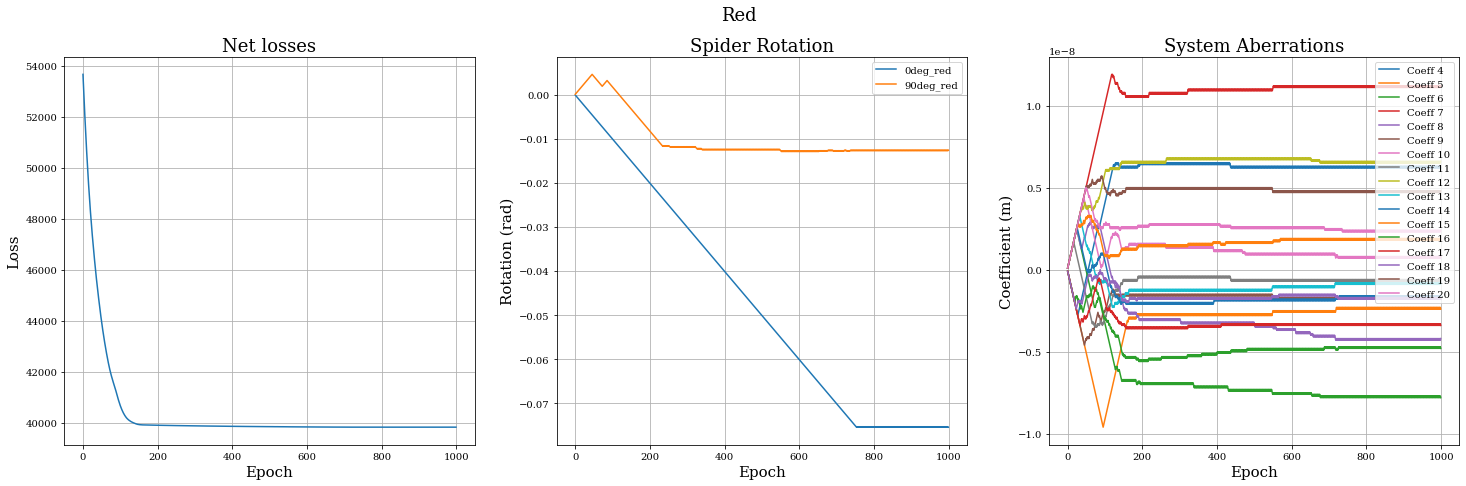

In [18]:
stored_params_dict= pickle.load(open(filenames[0], 'rb'))
plt.figure(figsize=(25,7))
plt.suptitle("Red")
plt.subplot(1,3,1)
plt.title("Net losses")
plt.plot(stored_params_dict["net loss"])
plt.xlabel("Epoch")
plt.grid()
plt.ylabel("Loss")

plt.subplot(1,3,3)
plt.title("System Aberrations")
coeffs_arr = np.asarray(stored_params_dict["aperture.coefficients"])[:,0,:]
for l in range(coeffs_arr.shape[-1]):
    label = "Coeff " + str(zernike_indicies[l])
    plt.plot(coeffs_arr[:,l], label=label)
plt.legend()
plt.ylabel("Coefficient (m)")
plt.xlabel("Epoch")
plt.grid()

plt.subplot(1,3,2)
plt.title("Spider Rotation")
for i, filename in enumerate(filenames):
    stored_params_dict = pickle.load(open(filename, 'rb'))
    plt.plot(np.asarray(stored_params_dict["spider.rotation"])[:,0,0], label=labels[i])
plt.ylabel("Rotation (rad)")
plt.xlabel("Epoch")
plt.legend()
plt.grid()

Save figures for each model fit, for both configs

In [19]:
config_stored_params = [pickle.load(open(filenames[0], 'rb')),
                          pickle.load(open(filenames[1], 'rb'))]
config_models = optimisation_manager.models
config_labels = ["sp180", "sp270"]


In [20]:
for frame_n in range(frames_i.shape[0]):
    plt.figure(figsize=(16,18))
    plt.subplot(4,3,1)
    for i, stored_params_dict in enumerate(config_stored_params):
        pos = np.asarray(stored_params_dict["source.position"])
        Positions_sp180 = pos[:,frame_n,0]
        Positions_sp270 = pos[:,frame_n,1]
        plt.plot(Positions_sp180, label="Position X - {}".format(config_labels[i]))
        plt.plot(Positions_sp270, label="Position Y - {}".format(config_labels[i]))
    plt.title("Source Position")
    plt.legend()

    plt.subplot(4,3,2)
    coeffs_arr = np.asarray(stored_params_dict["aperture.coefficients"])[:,frame_n,:]
    for l in range(coeffs_arr.shape[-1]):
        label = "Coeff " + str(zernike_indicies[l])
        plt.plot(coeffs_arr[:,l], label=label)
    plt.legend()
    plt.title("Plate Zern Coefficients")

    plt.subplot(4,3,3)
    for i, stored_params_dict in enumerate(config_stored_params):
        fluxes_arr = np.asarray(stored_params_dict["source.flux"])
        plt.plot(fluxes_arr[:,frame_n,:], label="config{}".format(config_labels[i]))
    plt.title("Flux")
    plt.legend()

    plt.subplot(4,3,4)
    for i, stored_params_dict in enumerate(config_stored_params):
        spider_rot_arr = np.asarray(stored_params_dict["spider.rotation"])
        plt.plot(spider_rot_arr[:,frame_n,:], label="Spider {}".format(config_labels[i])) # any of the models here will yield same result for jointly fit
    plt.ylabel("Rotation (rad)")
    plt.xlabel("Epoch")

    it = 5
    spider_configs=[config_models[0][frame_n], config_models[1][frame_n]]
    for k, config in enumerate(spider_configs):
        plt.subplot(4,3,it)
        # print(config.source.spectrum.wavelengths)
        opd = config.aperture.eval_basis()
        trans = config.spider.transmission
        plt.imshow(opd*trans, cmap='viridis')
        plt.title('Retrieved Aberrations - config {}'.format(k))
        plt.colorbar()
        it+=1

    for k, config in enumerate(spider_configs):
        scaled_data = optimisation_manager.OptimManagers[k].data[frame_n] 
        plt.subplot(4,3,it)
        norm_psf = PowerNorm(0.2, vmax=scaled_data.max(), vmin=scaled_data.min())
        plt.imshow(scaled_data, norm=norm_psf)
        plt.colorbar()
        plt.ylabel("Config {}".format(k))
        plt.title('Data')
        it+=1

        plt.subplot(4,3,it)
        model_psf = config.model()
        # current_range = model_psf.max() - model_psf.min()
        # new_range = scaled_data.max() - scaled_data.min()
        # model_psf = ( (model_psf - model_psf.min()) * new_range )/current_range + scaled_data.min()
        norm_psf = PowerNorm(0.2, vmax=model_psf.max(), vmin=model_psf.min())
        plt.imshow(model_psf*img_masks[frame_n][k], norm=norm_psf)
        plt.title('Model')
        plt.colorbar()
        it+=1

        plt.subplot(4,3,it)
        resid = scaled_data - model_psf
        plt.imshow(resid, cmap='bwr', vmax = np.abs(resid).max(), vmin = -np.abs(resid).max())
        plt.colorbar()
        plt.title('Residuals')
        it+=1

    plt.tight_layout()
    plt.savefig(save_dir+"combined/"+plate_name+"_red_frame_" + str(frame_n) + ".png")
    plt.close()

Summary statistics 

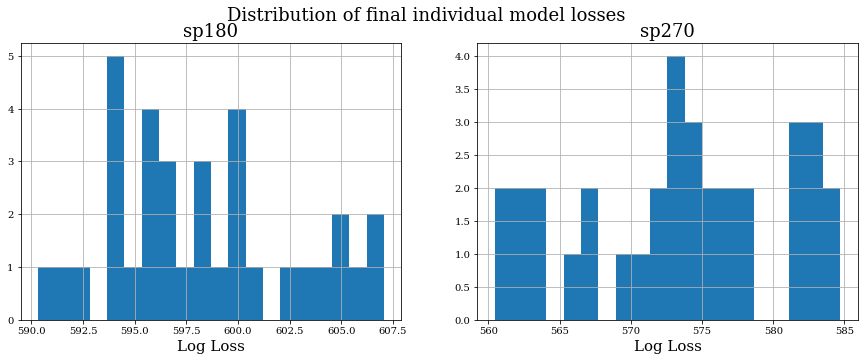

In [36]:
plt.figure(figsize=(15,5))
plt.suptitle("Distribution of final individual model losses")
it =1
for i, stored_params_dict in enumerate(config_stored_params):
    log_losses = np.asarray(stored_params_dict["final losses"]).flatten()
    plt.subplot(1,2,it)
    plt.title("{}".format(config_labels[i]))
    plt.hist(log_losses, bins=20)
    plt.xlabel("Log Loss")
    plt.grid()
    it +=1

In [37]:
# calc CRLB and save coeffs + associated uncertainties  
# called AFTER optimisation (i.e. evaluated at MLE)
CRLB = optimisation_manager.calc_CRLB(param="aperture.coefficients")
CRLB_max = [np.nanmax(crlb, axis=0) for crlb in CRLB] # take the maximum uncertainty
CRLB_max = np.nanmax(np.asarray(CRLB_max),axis=0) # max stdev over plate configs also
coeffs = optimisation_manager.OptimManagers[0].models[0].aperture.coefficients # any config for any frame model

all_coeffs = [ [model_i.aperture.coefficients for model_i in optim_i.models] for optim_i in optimisation_manager.OptimManagers]
all_coeffs = np.concatenate(all_coeffs) 

ddict = {}
ddict['value'] = coeffs
ddict['stdev']=CRLB_max
ddict['stdev_data']= np.nanstd(all_coeffs, axis=0)
ddict['SEM']=CRLB_max/np.sqrt(frames_i.shape[0])
print("Calculating SEM over {} frames".format(frames_i.shape[0]))
pickle.dump(ddict, open(save_dir+plate_name+"_red_coeffs_dict.pkl", 'wb'))

Calculating SEM over 34 frames


red RMS WFE: 0.030lambda
Mean RMS WFE: 0.030lambda


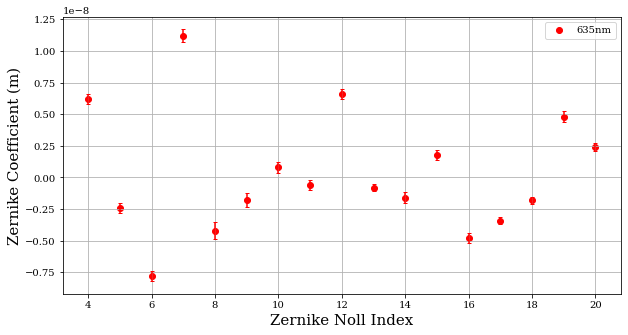

In [38]:
# plot this info
stored_coeffs = pickle.load(open(save_dir +plate_name+ "_red_coeffs_dict.pkl",'rb'))
mean, stdev = stored_coeffs["value"], stored_coeffs["SEM"]

plt.figure(figsize=(10,5))
wf_errs = []
labels = ['red']
stdevs = [stdev]
for i,coeffs in enumerate([mean]):

    if 'red' in labels[i]:
        wl = red_laser_wl
        colour = 'r'
    elif 'green' in labels[i]:
        wl = green_laser_wl
        colour = 'g'
    else:
        ValueError("Unknown Wavelength")

    plt.scatter(zernike_indicies, coeffs, label=str(round(wl*1e9))+"nm", c=colour)
    plt.errorbar(zernike_indicies, coeffs, yerr=stdevs[i]/2,ecolor=colour, capsize=2,linestyle='')
    RMS_wf_err = ((coeffs**2).sum())**0.5

    print("{} RMS WFE: {:.3f}lambda".format(labels[i], RMS_wf_err/wl))
    wf_errs.append(RMS_wf_err/wl) 

plt.xlabel("Zernike Noll Index")
plt.ylabel("Zernike Coefficient (m)")
plt.grid()
plt.legend()

print("Mean RMS WFE: {:.3f}lambda".format(np.mean(wf_errs)))

#### Starphire 2

In [50]:
img_fnames = [
    # "non_glued/14_04_2025/14_04_plate2_0deg_green_80us_0gain_img_stack_batch_0.npy",
    # "non_glued/14_04_2025/14_04_plate2_90deg_green_80us_0gain_img_stack_batch_0.npy",
    "non_glued/12_01_2026/12_01_2026_plate#4_0deg_red_173us_0gain_Xoff3340_Yoff1840_img_stack_batch_0.npy",
    "non_glued/12_01_2026/12_01_2026_plate#4_90deg_red_173us_0gain_Xoff3340_Yoff1840_img_stack_batch_0.npy",
    
]
labels = [
    # "0deg_green",
    # "90deg_green",
    "0deg_red",
    "90deg_red",
]
bckgnd_fnames = [
    # "non_glued/14_04_2025/14_04_0deg_green_bckgnd_80us_0gain_img_stack_batch_0.npy",
    # "non_glued/14_04_2025/14_04_plate2_90deg_green_bckgnd_80us_0gain_img_stack_batch_0.npy",
    # "non_glued/12_01_2026/08_01_2026_plate#4_0deg_red_bckgnd173us_0gain_img_stack_batch_0.npy",
    # "non_glued/12_01_2026/08_01_2026_plate#4_90deg_red_bckgnd173us_0gain_img_stack_batch_0.npy",
]
still_frame_idxs = [
    0, 0, 0, 0 # find_still_frame.py
]
imgs = jnp.asarray([np.flip(np.load(data_dir+img_fname)) for img_fname in img_fnames])
n_frames = 30   #number of frames to perform phase retrieval on
step_sz = int(imgs[0].shape[0]/n_frames) # step size for frames (equally spaced frame grabs)

bckgnds = jnp.asarray([np.mean(np.flip(np.load(data_dir+bckgnd_fname)),axis=0) for bckgnd_fname in bckgnd_fnames])  # single bck

In [41]:
plate_name = "plate2"

In [51]:
frames_i = np.arange(0, imgs.shape[1], step_sz) # indices to sample frame
# frames_i = np.array([0,1,3])

# instrument_sp180_g = dl.Telescope(optics_sp180, ('source', green_src))
# instrument_sp270_g = dl.Telescope(optics_sp270, ('source', green_src))
instrument_sp180_r = dl.Telescope(optics_sp180, ('source', red_src))
instrument_sp270_r = dl.Telescope(optics_sp270, ('source', red_src))
sim_psfs = [instrument_sp180_r.model(), instrument_sp270_r.model()]

linear_imgs = []
img_masks = []
for frame_n in frames_i:
    data_sp180_r = imgs[0][frame_n,:,:] 
    data_sp270_r = imgs[1][frame_n,:,:]

    data_list = [data_sp180_r, data_sp270_r]
    masks = []
    scaled_data_list = []
    for j in range(len(data_list)):
        data = data_list[j]
        if len(bckgnds) > 0:
            data = data - bckgnds[j]
        m = jnp.ones(data.shape)
        m = m.at[data <= 255].set(0.0)

        # Reverse-model detector response
        data_remapped = 0.0 + ((1.0 - 0.0)/(data.max()-data.min()))*(data - data.min()) #[0,1] otput range
        data = np.power((data_remapped-alpha_cropped)/beta_cropped, (1/gamma_cropped)) 

        # Scale intensity
        current_range = data.max() - data.min()
        new_range = sim_psfs[j].max() - sim_psfs[j].min()
        scaled_data = ( (data - data.min()) * new_range )/current_range + sim_psfs[j].min()

        psf_center_idx = np.unravel_index(np.argmax(scaled_data, axis=None), scaled_data.shape)
        scaled_data = scaled_data[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
        masks.append(m[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz])
        
        scaled_data_list.append(scaled_data)

    linear_imgs.append(scaled_data_list)
    img_masks.append(masks)

linear_imgs = jnp.asarray(linear_imgs)
img_masks = jnp.asarray(img_masks)


In [52]:
# Create models - one per frame of data
configs = [instrument_sp180_r, instrument_sp270_r] # model configurations to optimise upon
models = []
for i, instrument_model in enumerate(configs):
    # make x copies of the model, one for each frame of data
    temp_config = [instrument_model]*frames_i.shape[0]
    models.append(temp_config)


In [53]:
# Create optimisation managers - one per spider configuration
OMS = []
for i in range(len(models)):
    om = OptimManager(
        models=models[i],
        data=linear_imgs[:,i,:,:], 
        params=params,
        loss_fn="poisson", # poisson loss for photon counting
        optimisers=optimisers,
        jointly_fit_params=["spider.rotation"], # each config has a unique spider orientation - jointly fit for that over time/frames
    )

    OMS.append(om)

# Create a joint optimisation manager to optimise the system aberrations over both spider configs
optimisation_manager = JointOptimManager(optim_managers=OMS,
                                        jointly_fit_params=["aperture.coefficients"], # coefficients should be same over time over both spider orientations
                                        )

In [ ]:
optimisation_manager.run_optimisation(num_steps=1000)


Loss:   0%|          | 0/1000 [00:00<?, ?it/s]

In [52]:
filenames = [save_dir+plate_name+"_red_0deg_stored_params_dict.pkl", save_dir+plate_name+"_red_90deg_stored_params_dict.pkl"]
optimisation_manager.save_stored_params(filenames=filenames)

Stored parameters saved to data/non_glued/12_01_2026/plate2_red_0deg_stored_params_dict.pkl
Stored parameters saved to data/non_glued/12_01_2026/plate2_red_90deg_stored_params_dict.pkl


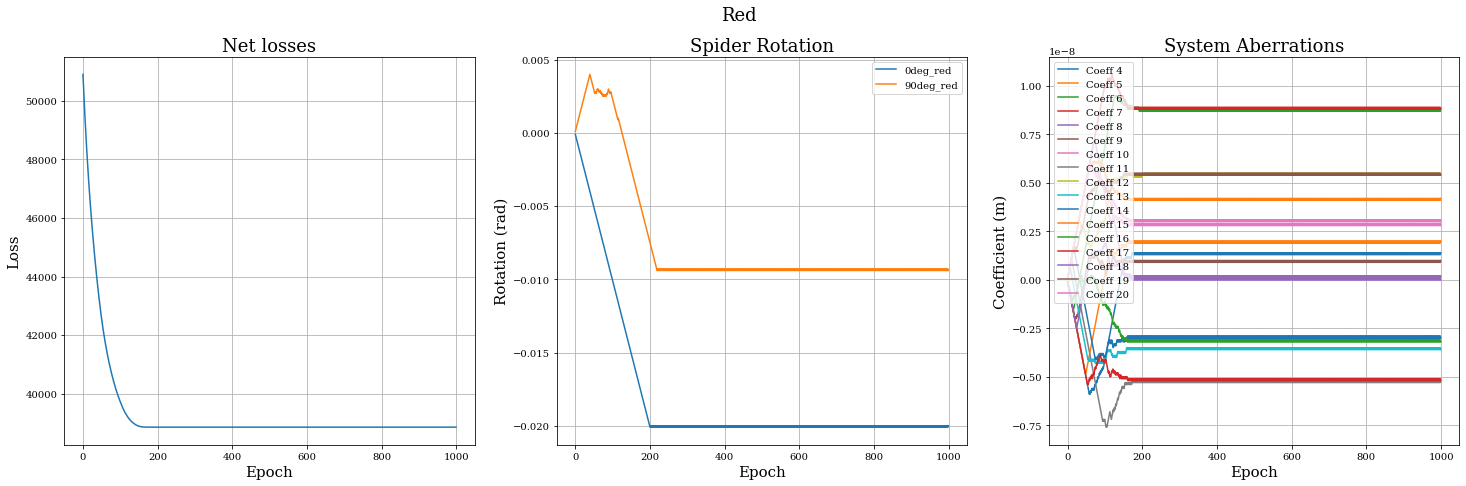

In [53]:
stored_params_dict= pickle.load(open(filenames[0], 'rb'))
plt.figure(figsize=(25,7))
plt.suptitle("Red")
plt.subplot(1,3,1)
plt.title("Net losses")
plt.plot(stored_params_dict["net loss"])
plt.xlabel("Epoch")
plt.grid()
plt.ylabel("Loss")

plt.subplot(1,3,3)
plt.title("System Aberrations")
coeffs_arr = np.asarray(stored_params_dict["aperture.coefficients"])[:,0,:]
for l in range(coeffs_arr.shape[-1]):
    label = "Coeff " + str(zernike_indicies[l])
    plt.plot(coeffs_arr[:,l], label=label)
plt.legend()
plt.ylabel("Coefficient (m)")
plt.xlabel("Epoch")
plt.grid()

plt.subplot(1,3,2)
plt.title("Spider Rotation")
for i, filename in enumerate(filenames):
    stored_params_dict = pickle.load(open(filename, 'rb'))
    plt.plot(np.asarray(stored_params_dict["spider.rotation"])[:,0,0], label=labels[i])
plt.ylabel("Rotation (rad)")
plt.xlabel("Epoch")
plt.legend()
plt.grid()

In [54]:
config_stored_params = [pickle.load(open(filenames[0], 'rb')),
                          pickle.load(open(filenames[1], 'rb'))]
config_models = optimisation_manager.models
config_labels = ["sp180", "sp270"]


In [55]:
for frame_n in range(frames_i.shape[0]):
    plt.figure(figsize=(16,18))
    plt.subplot(4,3,1)
    for i, stored_params_dict in enumerate(config_stored_params):
        pos = np.asarray(stored_params_dict["source.position"])
        Positions_sp180 = pos[:,frame_n,0]
        Positions_sp270 = pos[:,frame_n,1]
        plt.plot(Positions_sp180, label="Position X - {}".format(config_labels[i]))
        plt.plot(Positions_sp270, label="Position Y - {}".format(config_labels[i]))
    plt.title("Source Position")
    plt.legend()

    plt.subplot(4,3,2)
    coeffs_arr = np.asarray(stored_params_dict["aperture.coefficients"])[:,frame_n,:]
    for l in range(coeffs_arr.shape[-1]):
        label = "Coeff " + str(zernike_indicies[l])
        plt.plot(coeffs_arr[:,l], label=label)
    plt.legend()
    plt.title("Plate Zern Coefficients")

    plt.subplot(4,3,3)
    for i, stored_params_dict in enumerate(config_stored_params):
        fluxes_arr = np.asarray(stored_params_dict["source.flux"])
        plt.plot(fluxes_arr[:,frame_n,:], label="config{}".format(config_labels[i]))
    plt.title("Flux")
    plt.legend()

    plt.subplot(4,3,4)
    for i, stored_params_dict in enumerate(config_stored_params):
        spider_rot_arr = np.asarray(stored_params_dict["spider.rotation"])
        plt.plot(spider_rot_arr[:,frame_n,:], label="Spider {}".format(config_labels[i])) # any of the models here will yield same result for jointly fit
    plt.ylabel("Rotation (rad)")
    plt.xlabel("Epoch")

    it = 5
    spider_configs=[config_models[0][frame_n], config_models[1][frame_n]]
    for k, config in enumerate(spider_configs):
        plt.subplot(4,3,it)
        # print(config.source.spectrum.wavelengths)
        opd = config.aperture.eval_basis()
        trans = config.spider.transmission
        plt.imshow(opd*trans, cmap='viridis')
        plt.title('Retrieved Aberrations - config {}'.format(k))
        plt.colorbar()
        it+=1

    for k, config in enumerate(spider_configs):
        scaled_data = optimisation_manager.OptimManagers[k].data[frame_n] 
        plt.subplot(4,3,it)
        norm_psf = PowerNorm(0.2, vmax=scaled_data.max(), vmin=scaled_data.min())
        plt.imshow(scaled_data, norm=norm_psf)
        plt.colorbar()
        plt.ylabel("Config {}".format(k))
        plt.title('Data')
        it+=1

        plt.subplot(4,3,it)
        model_psf = config.model()
        # current_range = model_psf.max() - model_psf.min()
        # new_range = scaled_data.max() - scaled_data.min()
        # model_psf = ( (model_psf - model_psf.min()) * new_range )/current_range + scaled_data.min()
        norm_psf = PowerNorm(0.2, vmax=model_psf.max(), vmin=model_psf.min())
        plt.imshow(model_psf*img_masks[frame_n][k], norm=norm_psf)
        plt.title('Model')
        plt.colorbar()
        it+=1

        plt.subplot(4,3,it)
        resid = scaled_data - model_psf
        plt.imshow(resid, cmap='bwr', vmax = np.abs(resid).max(), vmin = -np.abs(resid).max())
        plt.colorbar()
        plt.title('Residuals')
        it+=1

    plt.tight_layout()
    plt.savefig(save_dir+"combined/"+plate_name+"_red_frame_" + str(frame_n) + ".png")
    plt.close()

Summary stats

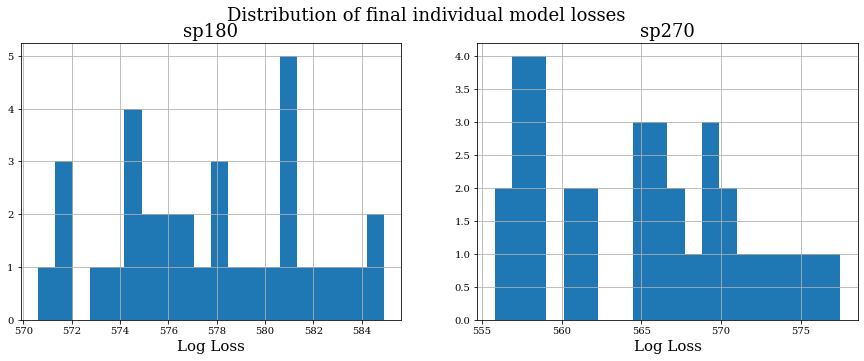

In [56]:
plt.figure(figsize=(15,5))
plt.suptitle("Distribution of final individual model losses")
it =1
for i, stored_params_dict in enumerate(config_stored_params):
    log_losses = np.asarray(stored_params_dict["final losses"]).flatten()
    plt.subplot(1,2,it)
    plt.title("{}".format(config_labels[i]))
    plt.hist(log_losses, bins=20)
    plt.xlabel("Log Loss")
    plt.grid()
    it +=1

In [58]:
CRLB = optimisation_manager.calc_CRLB(param="aperture.coefficients")
CRLB_max = [np.nanmax(crlb, axis=0) for crlb in CRLB] # take the maximum uncertainty
CRLB_max = np.nanmax(np.asarray(CRLB_max),axis=0) # max stdev over plate configs also
coeffs = optimisation_manager.OptimManagers[0].models[0].aperture.coefficients # any config for any frame model

all_coeffs = [ [model_i.aperture.coefficients for model_i in optim_i.models] for optim_i in optimisation_manager.OptimManagers]
all_coeffs = np.concatenate(all_coeffs) 

ddict = {}
ddict['value'] = coeffs
ddict['stdev']=CRLB_max
ddict['stdev_data']= np.nanstd(all_coeffs, axis=0)
ddict['SEM']=CRLB_max/np.sqrt(frames_i.shape[0])
print("Calculating SEM over {} frames".format(frames_i.shape[0]))
pickle.dump(ddict, open(save_dir+plate_name+"_red_coeffs_dict.pkl", 'wb'))

Calculating SEM over 34 frames


red RMS WFE: 0.029lambda
Mean RMS WFE: 0.029lambda


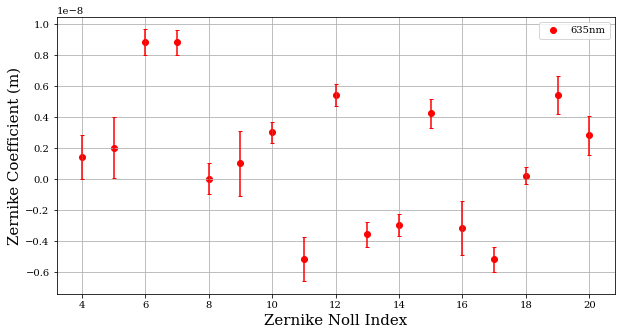

In [60]:
# plot this info
stored_coeffs = pickle.load(open(save_dir +plate_name+ "_red_coeffs_dict.pkl",'rb'))
mean, stdev = stored_coeffs["value"], stored_coeffs["SEM"]

plt.figure(figsize=(10,5))
wf_errs = []
labels = ['red']
stdevs = [stdev]
for i,coeffs in enumerate([mean]):

    if 'red' in labels[i]:
        wl = red_laser_wl
        colour = 'r'
    elif 'green' in labels[i]:
        wl = green_laser_wl
        colour = 'g'
    else:
        ValueError("Unknown Wavelength")

    plt.scatter(zernike_indicies, coeffs, label=str(round(wl*1e9))+"nm", c=colour)
    plt.errorbar(zernike_indicies, coeffs, yerr=stdevs[i]/2,ecolor=colour, capsize=2,linestyle='')
    RMS_wf_err = ((coeffs**2).sum())**0.5

    print("{} RMS WFE: {:.3f}lambda".format(labels[i], RMS_wf_err/wl))
    wf_errs.append(RMS_wf_err/wl) 

plt.xlabel("Zernike Noll Index")
plt.ylabel("Zernike Coefficient (m)")
plt.grid()
plt.legend()

print("Mean RMS WFE: {:.3f}lambda".format(np.mean(wf_errs)))

______________________________________________________________________________________________________________________________________________________________________________________________

#### Glued plates

Post pre-cure.

New syst aberrations

In [8]:
f_aberr = "data/spider/retrieval_results/18_09_2025/system_coeffs_dict.pkl"

syst_noll = jnp.arange(4, 15) # only first 14 Zernike modes (excluding piston and tip/tilt) are used to classify syst aberrations
# syst_coeffs = jnp.load(f_aberr)
syst_coeffs = pickle.load(open(f_aberr, "rb"))["value"]
syst_basis = dlu.zernike_basis(js=syst_noll, diameter=aperture_diameter, coordinates=coords)
print("System Coefficients (noll {}): {}".format(syst_noll,syst_coeffs))


System Coefficients (noll [ 4  5  6  7  8  9 10 11 12 13 14]): [-2.38e-08 -2.40e-09 -1.22e-08  5.20e-09  6.00e-09 -2.10e-08 -3.00e-09
  3.48e-08 -1.80e-09  4.80e-09 -1.10e-08]


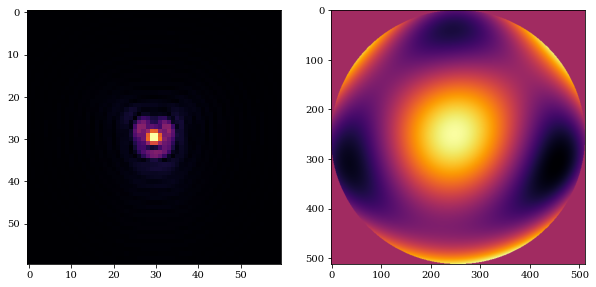

In [9]:
# Re-create base models with new syst aberrations
psf_npix = 60                 # Number of pixels along one dim of the PSF
psf_hlf_sz = int(psf_npix/2)   # half window sz of cropped data
zernike_indicies = jnp.arange(4, 31) 
coeffs = jnp.zeros(zernike_indicies.shape)
basis = dlu.zernike_basis(js=zernike_indicies, coordinates=coords, diameter=aperture_diameter)
optical_systems = []
transmissions = []
for i in range(len(spider_angles)):
    spider = dlu.spider(coords=coords, width=spider_width, angles=[spider_angles[i]])
    transmission = dlu.combine([circle, spider])

    layers = [
        ('SystemAberrations', dl.layers.BasisOptic(basis=syst_basis, coefficients=syst_coeffs, normalise=False)),
        ('intensity', dl.layers.TransmissiveLayer(transmission=intensity_dist, normalise=False)),
        ('spider', TransmissiveLayer(transmission=transmission, normalise=False)),
        ('aperture', dl.layers.BasisOptic(basis=basis, transmission=None, coefficients=coeffs, normalise=False)),
    ]
    optics = dl.AngularOpticalSystem(wf_npixels = wf_npixels, 
                                diameter=wf_diam, 
                                layers=layers, 
                                psf_npixels=psf_npix, 
                                psf_pixel_scale=psf_pixel_scale,
                                oversample=oversample)

    optical_systems.append(optics)
    transmissions.append(transmission)

# Construct Optics
optics_sp270  = optical_systems[0]
optics_sp180 = optical_systems[1]

# Check PSF for aberrated system
layers = [
    ('SystemAberrations', dl.layers.BasisOptic(syst_basis, circle*intensity_dist, syst_coeffs, normalise=False)),
]

optics = dl.AngularOpticalSystem(wf_npixels = wf_npixels, 
                            diameter=wf_diam, 
                            layers=layers, 
                            psf_npixels=psf_npix, 
                            psf_pixel_scale=psf_pixel_scale,
                            oversample=oversample)

psf = optics.propagate_mono(green_laser_wl)
plt.subplot(1,2,1)
plt.imshow(jnp.flip(psf)**0.5)
# plt.xlim([200,250])
# plt.ylim([200,250])
opd = optics.SystemAberrations.eval_basis()
plt.subplot(1,2,2)
plt.imshow(opd)


In [10]:
row_start, col_start = 1900, 2892 # Start coord of window on det where data was taken
row_len, col_len = 150, 152   # window size of recorded data

alpha_cropped = jnp.flip(alpha[row_start:row_start+row_len, col_start:col_start+col_len])
beta_cropped = jnp.flip(beta[row_start:row_start+row_len, col_start:col_start+col_len])
gamma_cropped = jnp.flip(gamma[row_start:row_start+row_len, col_start:col_start+col_len])

# Order in increasing spider angle for each colour separately
img_fnames = [
    # "glued/28_07_2025/28_07_0deg_green_93us_0gain_img_stack_batch_0.npy",
    # "glued/28_07_2025/28_07_90deg_green_120us_0gain_img_stack_batch_0.npy",
    # "glued/26_08_2025/defoc_26_08_2025_0deg_red_80us_0gain_img_stack_batch_0.npy",
    # "glued/26_08_2025/defoc_26_08_2025_90deg_red_80us_0gain_img_stack_batch_0.npy",
    "glued/18_09_2025/18_09_2025_0deg_red_93us_0gain_img_stack_batch_0.npy",
    "glued/18_09_2025/18_09_2025_90deg_red_93us_0gain_img_stack_batch_0.npy"

]

labels = [
    # "0deg_green",
    # "90deg_green",
    "0deg_red",
    "90deg_red",
]
bckgnd_fnames = [
    # "glued/28_07_2025/28_07_0deg_green_bckgnd_93us_0gain_img_stack_batch_0.npy",
    # "glued/28_07_2025/28_07_90deg_green_bckgnd_120us_0gain_img_stack_batch_0.npy",
    "glued/18_09_2025/18_09_2025_0deg_red_bckgnd_93us_0gain_img_stack_batch_0.npy",
    "glued/18_09_2025/18_09_2025_90deg_red_bckgnd_93us_0gain_img_stack_batch_0.npy",
]

imgs = jnp.asarray([np.flip(np.load(data_dir+img_fname)) for img_fname in img_fnames])
n_frames = 30   #number of frames to perform phase retrieval on
step_sz = int(imgs[0].shape[0]/n_frames) # step size for frames (equally spaced frame grabs)

bckgnds = jnp.asarray([np.mean(np.flip(np.load(data_dir+bckgnd_fname)),axis=0) for bckgnd_fname in bckgnd_fnames])  # single bck



In [11]:
save_dir = "data/glued/18_09_2025/"
plate_name = "glued"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
elif len(os.listdir(save_dir)) != 0:
    print("Warning: Files already exist in root directory. ")
if not os.path.exists(save_dir+"combined/"):
    os.makedirs(save_dir+"combined/")
elif len(os.listdir(save_dir+"combined/")) != 0:
    print("Warning: Files already exist in root directory. ")

In [12]:
frames_i = np.arange(0, imgs.shape[1], step_sz) # indices to sample frame
# frames_i = np.array([0,1])

# instrument_sp180_g = dl.Telescope(optics_sp180, ('source', green_src))
# instrument_sp270_g = dl.Telescope(optics_sp270, ('source', green_src))
instrument_sp180_r = dl.Telescope(optics_sp180, ('source', red_src))
instrument_sp270_r = dl.Telescope(optics_sp270, ('source', red_src))
sim_psfs = [instrument_sp180_r.model(), instrument_sp270_r.model()]

linear_imgs = []
img_masks = []
for frame_n in frames_i:
    data_sp180_r = imgs[0][frame_n,:,:] 
    data_sp270_r = imgs[1][frame_n,:,:]

    data_list = [data_sp180_r, data_sp270_r]
    masks = []
    scaled_data_list = []
    for j in range(len(data_list)):
        data = data_list[j]
        if len(bckgnds) > 0:
            data = data - bckgnds[j]
        m = jnp.ones(data.shape)
        m = m.at[data <= 255].set(0.0)

        # Reverse-model detector response
        data_remapped = 0.0 + ((1.0 - 0.0)/(data.max()-data.min()))*(data - data.min()) #[0,1] otput range
        data = np.power((data_remapped-alpha_cropped)/beta_cropped, (1/gamma_cropped)) 

        # Scale intensity
        current_range = data.max() - data.min()
        new_range = sim_psfs[j].max() - sim_psfs[j].min()
        scaled_data = ( (data - data.min()) * new_range )/current_range + sim_psfs[j].min()

        psf_center_idx = np.unravel_index(np.argmax(scaled_data, axis=None), scaled_data.shape)
        scaled_data = scaled_data[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
        masks.append(m[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz])
        
        scaled_data_list.append(scaled_data)

    linear_imgs.append(scaled_data_list)
    img_masks.append(masks)

linear_imgs = jnp.asarray(linear_imgs)
img_masks = jnp.asarray(img_masks)


In [13]:
params = [
    "aperture.coefficients",
    "spider.rotation",
    "source.position",
    "source.flux", 
    ]


optimisers = [
            optax.adam(learning_rate=1e-10),
            optax.adam(learning_rate=1e-4),
            optax.adam(learning_rate=1e-9),
            optax.adam(learning_rate=1e7),
              ]

In [14]:
# init w/ 2 plate aberration
ng_dir = "data/non_glued/08_09_2025/"
p1,p2 = pickle.load(open(ng_dir+"plate1_red_coeffs_dict.pkl", 'rb'))['value'], pickle.load(open(ng_dir+"plate2_red_coeffs_dict.pkl", 'rb'))['value']
init_z_coeffs = jnp.zeros(zernike_indicies.shape)
init_z_coeffs = init_z_coeffs.at[:p1.shape[0]].set(p1+p2) # sum of the 2 plates

In [15]:
# Create models - one per frame of data
configs = [instrument_sp180_r, instrument_sp270_r] # model configurations to optimise upon
models = []
init_coeffs = True
for i, instrument_model in enumerate(configs):
    # make x copies of the model, one for each frame of data
    if init_coeffs:
        instrument_model = instrument_model.set("aperture.coefficients", init_z_coeffs)
        
    temp_config = [instrument_model]*frames_i.shape[0]
    models.append(temp_config)


In [16]:
# Create optimisation managers - one per spider configuration
OMS = []
for i in range(len(models)):
    om = OptimManager(
        models=models[i],
        data=linear_imgs[:,i,:,:], 
        params=params,
        loss_fn="poisson", # poisson loss for photon counting
        optimisers=optimisers,
        jointly_fit_params=["spider.rotation"], # each config has a unique spider orientation - jointly fit for that over time/frames
    )

    OMS.append(om)

# Create a joint optimisation manager to optimise the system aberrations over both spider configs
optimisation_manager = JointOptimManager(optim_managers=OMS,
                                        jointly_fit_params=["aperture.coefficients"], # coefficients should be same over time over both spider orientations
                                        )

In [ ]:
optimisation_manager.run_optimisation(num_steps=3500)

Loss:   0%|          | 0/3500 [00:00<?, ?it/s]

In [18]:
filenames = [save_dir+plate_name+"_red_0deg_stored_params_dict.pkl", save_dir+plate_name+"_red_90deg_stored_params_dict.pkl"]
optimisation_manager.save_stored_params(filenames=filenames)

Stored parameters saved to data/glued/18_09_2025/glued_red_0deg_stored_params_dict.pkl
Stored parameters saved to data/glued/18_09_2025/glued_red_90deg_stored_params_dict.pkl


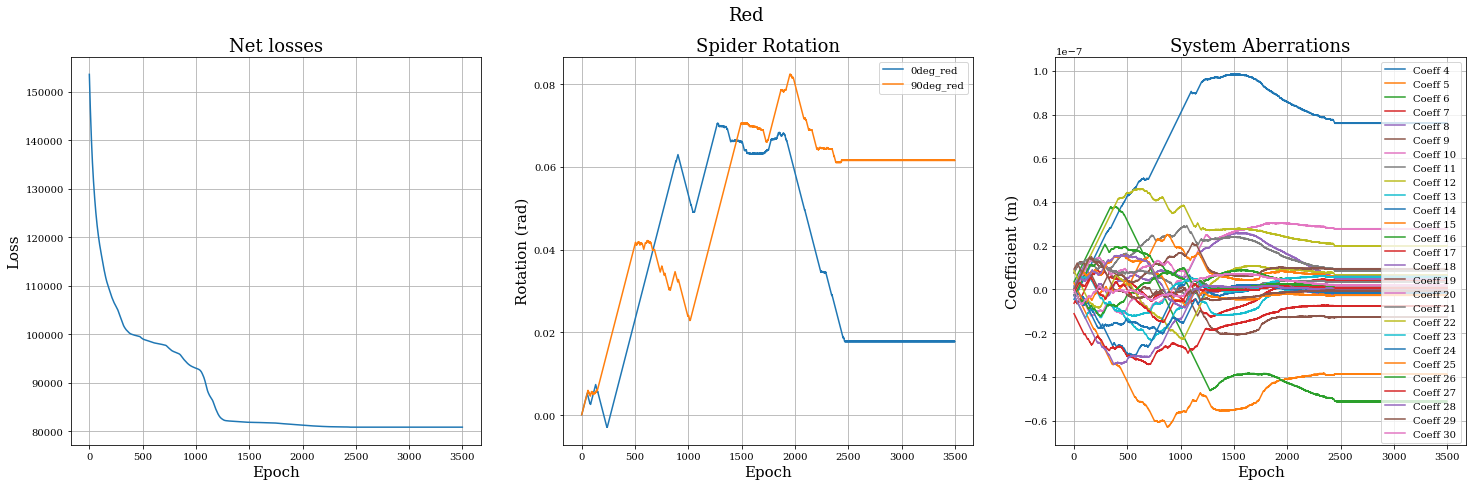

In [19]:
stored_params_dict= pickle.load(open(filenames[0], 'rb'))
plt.figure(figsize=(25,7))
plt.suptitle("Red")
plt.subplot(1,3,1)
plt.title("Net losses")
plt.plot(stored_params_dict["net loss"])
plt.xlabel("Epoch")
plt.grid()
plt.ylabel("Loss")

plt.subplot(1,3,3)
plt.title("System Aberrations")
coeffs_arr = np.asarray(stored_params_dict["aperture.coefficients"])[:,0,:]
for l in range(coeffs_arr.shape[-1]):
    label = "Coeff " + str(zernike_indicies[l])
    plt.plot(coeffs_arr[:,l], label=label)
plt.legend()
plt.ylabel("Coefficient (m)")
plt.xlabel("Epoch")
plt.grid()

plt.subplot(1,3,2)
plt.title("Spider Rotation")
for i, filename in enumerate(filenames):
    stored_params_dict = pickle.load(open(filename, 'rb'))
    plt.plot(np.asarray(stored_params_dict["spider.rotation"])[:,0,0], label=labels[i])
plt.ylabel("Rotation (rad)")
plt.xlabel("Epoch")
plt.legend()
plt.grid()

In [20]:
config_stored_params = [pickle.load(open(filenames[0], 'rb')),
                          pickle.load(open(filenames[1], 'rb'))]
config_models = optimisation_manager.models
config_labels = ["sp180", "sp270"]


In [29]:
for frame_n in range(frames_i.shape[0]):
    plt.figure(figsize=(16,18))
    plt.subplot(4,3,1)
    for i, stored_params_dict in enumerate(config_stored_params):
        pos = np.asarray(stored_params_dict["source.position"])
        Positions_sp180 = pos[:,frame_n,0]
        Positions_sp270 = pos[:,frame_n,1]
        plt.plot(Positions_sp180, label="Position X - {}".format(config_labels[i]))
        plt.plot(Positions_sp270, label="Position Y - {}".format(config_labels[i]))
    plt.title("Source Position")
    plt.legend()

    plt.subplot(4,3,2)
    coeffs_arr = np.asarray(stored_params_dict["aperture.coefficients"])[:,frame_n,:]
    for l in range(coeffs_arr.shape[-1]):
        label = "Coeff " + str(zernike_indicies[l])
        plt.plot(coeffs_arr[:,l], label=label)
    plt.legend()
    plt.title("Plate Zern Coefficients")

    plt.subplot(4,3,3)
    for i, stored_params_dict in enumerate(config_stored_params):
        fluxes_arr = np.asarray(stored_params_dict["source.flux"])
        plt.plot(fluxes_arr[:,frame_n,:], label="config{}".format(config_labels[i]))
    plt.title("Flux")
    plt.legend()

    plt.subplot(4,3,4)
    for i, stored_params_dict in enumerate(config_stored_params):
        spider_rot_arr = np.asarray(stored_params_dict["spider.rotation"])
        plt.plot(spider_rot_arr[:,frame_n,:], label="Spider {}".format(config_labels[i])) # any of the models here will yield same result for jointly fit
    plt.ylabel("Rotation (rad)")
    plt.xlabel("Epoch")

    it = 5
    spider_configs=[config_models[0][frame_n], config_models[1][frame_n]]
    for k, config in enumerate(spider_configs):
        plt.subplot(4,3,it)
        # print(config.source.spectrum.wavelengths)
        opd = config.aperture.eval_basis()
        trans = config.spider.transmission
        plt.imshow(opd*trans, cmap='viridis')
        plt.title('Retrieved Aberrations - config {}'.format(k))
        plt.colorbar()
        it+=1

    for k, config in enumerate(spider_configs):
        scaled_data = optimisation_manager.OptimManagers[k].data[frame_n] 
        plt.subplot(4,3,it)
        norm_psf = PowerNorm(0.2, vmax=scaled_data.max(), vmin=scaled_data.min())
        plt.imshow(scaled_data, norm=norm_psf)
        plt.colorbar()
        plt.ylabel("Config {}".format(k))
        plt.title('Data')
        it+=1

        plt.subplot(4,3,it)
        model_psf = config.model()
        # current_range = model_psf.max() - model_psf.min()
        # new_range = scaled_data.max() - scaled_data.min()
        # model_psf = ( (model_psf - model_psf.min()) * new_range )/current_range + scaled_data.min()
        norm_psf = PowerNorm(0.2, vmax=model_psf.max(), vmin=model_psf.min())
        plt.imshow(model_psf*img_masks[frame_n][k], norm=norm_psf)
        plt.title('Model')
        plt.colorbar()
        it+=1

        plt.subplot(4,3,it)
        resid = scaled_data - model_psf
        plt.imshow(resid, cmap='bwr', vmax = np.abs(resid).max(), vmin = -np.abs(resid).max())
        plt.colorbar()
        plt.title('Residuals')
        it+=1

    # plt.tight_layout()
    # break
    plt.savefig(save_dir+"combined/"+plate_name+"_red_frame_" + str(frame_n) + ".png")
    plt.close()

Summary stats

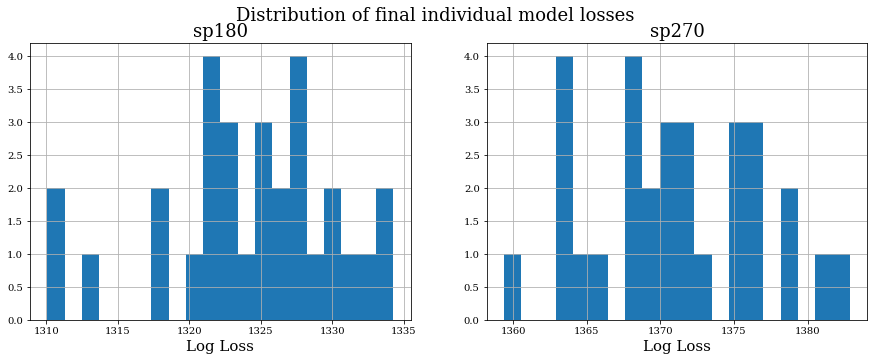

In [22]:
plt.figure(figsize=(15,5))
plt.suptitle("Distribution of final individual model losses")
it =1
for i, stored_params_dict in enumerate(config_stored_params):
    log_losses = np.asarray(stored_params_dict["final losses"]).flatten()
    plt.subplot(1,2,it)
    plt.title("{}".format(config_labels[i]))
    plt.hist(log_losses, bins=20)
    plt.xlabel("Log Loss")
    plt.grid()
    it +=1

In [23]:
# calc CRLB and save coeffs + associated uncertainties  
# called AFTER optimisation (i.e. evaluated at MLE)
CRLB = optimisation_manager.calc_CRLB(param="aperture.coefficients")
CRLB_max = [crlb.max(axis=0) for crlb in CRLB] # take the maximum uncertainty
CRLB_max = np.nanmax(np.asarray(CRLB_max),axis=0)
coeffs = optimisation_manager.OptimManagers[0].models[0].aperture.coefficients # any config for any frame model

ddict = {}
ddict['value'] = coeffs
ddict['stdev']=CRLB_max
ddict['SEM']=CRLB_max/np.sqrt(frames_i.shape[0])
print("Calculating SEM over {} frames".format(frames_i.shape[0]))
pickle.dump(ddict, open(save_dir+plate_name+"_red_coeffs_dict.pkl", 'wb'))

Calculating SEM over 30 frames


/tmp/ipykernel_1422269/3362112381.py:5: RuntimeWarning: All-NaN slice encountered
  CRLB_max = np.nanmax(np.asarray(CRLB_max),axis=0)


In [50]:
stored_coeffs = pickle.load(open(save_dir +plate_name+ "_red_coeffs_dict.pkl",'rb'))
stored_coeffs['value'].shape

(27,)

red RMS WFE: 0.170lambda
Mean RMS WFE: 0.170lambda


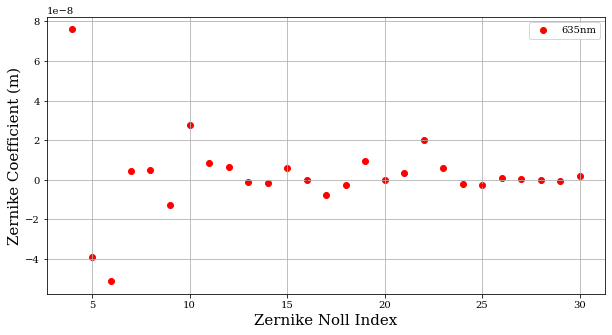

In [24]:
# plot this info
stored_coeffs = pickle.load(open(save_dir +plate_name+ "_red_coeffs_dict.pkl",'rb'))
mean, stdev = stored_coeffs["value"], stored_coeffs["SEM"]

plt.figure(figsize=(10,5))
wf_errs = []
labels = ['red']
stdevs = [stdev]
for i,coeffs in enumerate([mean]):

    if 'red' in labels[i]:
        wl = red_laser_wl
        colour = 'r'
    elif 'green' in labels[i]:
        wl = green_laser_wl
        colour = 'g'
    else:
        ValueError("Unknown Wavelength")

    plt.scatter(zernike_indicies, coeffs, label=str(round(wl*1e9))+"nm", c=colour)
    plt.errorbar(zernike_indicies, coeffs, yerr=stdevs[i],ecolor=colour, capsize=2,linestyle='')
    RMS_wf_err = ((coeffs**2).sum())**0.5

    print("{} RMS WFE: {:.3f}lambda".format(labels[i], RMS_wf_err/wl))
    wf_errs.append(RMS_wf_err/wl) 

plt.xlabel("Zernike Noll Index")
plt.ylabel("Zernike Coefficient (m)")
plt.grid()
plt.legend()

print("Mean RMS WFE: {:.3f}lambda".format(np.mean(wf_errs)))

Im plane

In [38]:
coeffs.shape

(17,)

Text(0.5, 1.0, 'Simulated')

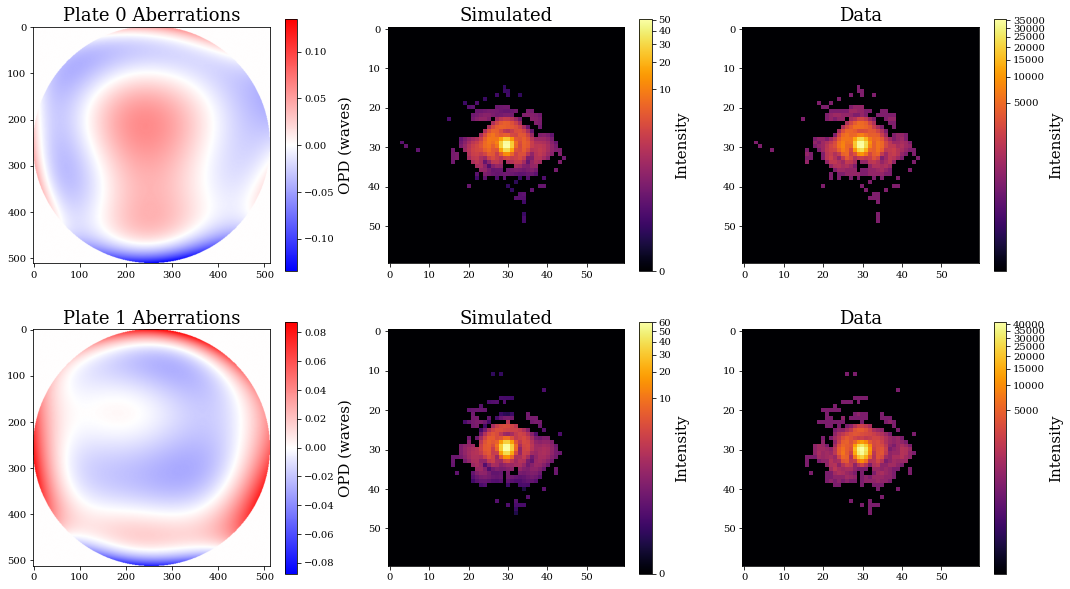

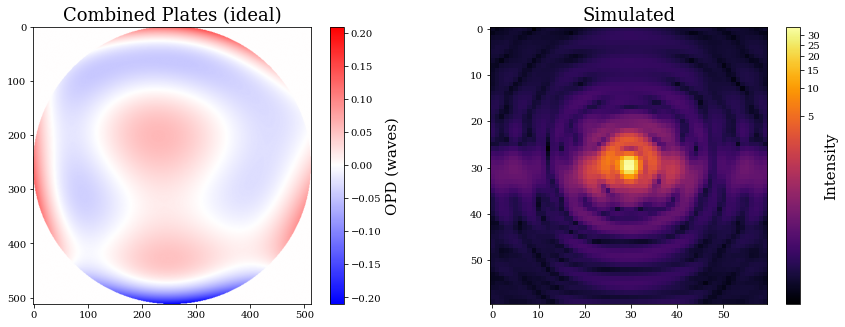

In [43]:
# separate plates 
# Pick single orientation + wl to show this (position+spider rotation assumed unchanged here - looking for general structure)

img_fnames = [ # 1 per plate. starphire 1 followed by 2
    "non_glued/08_09_2025/08_09_2025_plate1_0deg_red_93us_0gain_img_stack_batch_0.npy",
    "non_glued/08_09_2025/08_09_2025_plate2_0deg_red_93us_0gain_img_stack_batch_0.npy",
] 
imgs = jnp.asarray([np.flip(np.load(data_dir+img_fname)) for img_fname in img_fnames])

coeffs_dir = [
            "data/non_glued/08_09_2025/plate1_red_coeffs_dict.pkl", 
            "data/non_glued/08_09_2025/plate2_red_coeffs_dict.pkl",
]

plt.figure(figsize=(18,10))
subplt_it = 1
bases=[]
for i, dir in enumerate(coeffs_dir):
    # coeffs = np.load(dir)
    mean_coeffs = pickle.load(open(dir, 'rb'))['value']

    zern_basis = dlu.zernike_basis(js=jnp.arange(4,coeffs.shape[0]+4), diameter=aperture_diameter,coordinates=coords)
    plate_errors = dl.layers.BasisOptic(zern_basis, circle*intensity_dist, mean_coeffs, normalise=False)

    opd_basis = plate_errors.eval_basis()
    new_optics_sp180 = optics_sp180.insert_layer(layer=("plate", plate_errors), index=1)
    instrument_sp180 = dl.Telescope(new_optics_sp180, ('source', red_src))

    real_img = imgs[i][0]
    psf_center_idx = jnp.unravel_index(jnp.argmax(real_img, axis=None), real_img.shape)
    real_img = real_img[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                        psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
    real_img_mask = jnp.ones(real_img.shape)
    real_img_mask = real_img_mask.at[real_img == 255].set(0)

    plt.subplot(2,3,subplt_it)
    cnorm = CenteredNorm(vcenter=0)
    plt.imshow(opd_basis/red_laser_wl, norm=cnorm, cmap='bwr')
    plt.title("Plate {} Aberrations".format(i))
    plt.colorbar(label="OPD (waves)")
    subplt_it += 1
    plt.subplot(2,3,subplt_it)
    psf = instrument_sp180.model()
    pnorm = PowerNorm(0.2)
    plt.imshow(psf*real_img_mask, norm=pnorm)
    plt.colorbar(label="Intensity")
    plt.title("Simulated")
    subplt_it += 1
    plt.subplot(2,3,subplt_it)
    plt.imshow(real_img, norm=PowerNorm(0.2))
    plt.colorbar(label="Intensity")
    plt.title("Data")
    subplt_it += 1

    bases.append(plate_errors)

# Expected PSF from two aberrated plates
net_opd_basis = bases[0].eval_basis() + bases[1].eval_basis()


new_optics_sp180 = optics_sp180.insert_layer(layer=("plate1", bases[0]), index=1)
new_optics_sp180 = new_optics_sp180.insert_layer(layer=("plate2", bases[1]), index=1)
instrument_sp180 = dl.Telescope(new_optics_sp180, ('source', red_src))

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.imshow(net_opd_basis/red_laser_wl, norm=CenteredNorm(), cmap='bwr')
plt.colorbar(label="OPD (waves)")
plt.title("Combined Plates (ideal)")
plt.subplot(1,2,2)
psf = instrument_sp180.model()
plt.imshow(psf, norm=PowerNorm(0.2))
plt.colorbar(label="Intensity")
plt.title("Simulated")




In [46]:
zernike_indicies.shape

(27,)

In [51]:
save_dir +plate_name+ "_red_coeffs_dict.pkl"

'data/glued/18_09_2025/glued_red_coeffs_dict.pkl'

P-V WFE: 0.8686621029678042waves


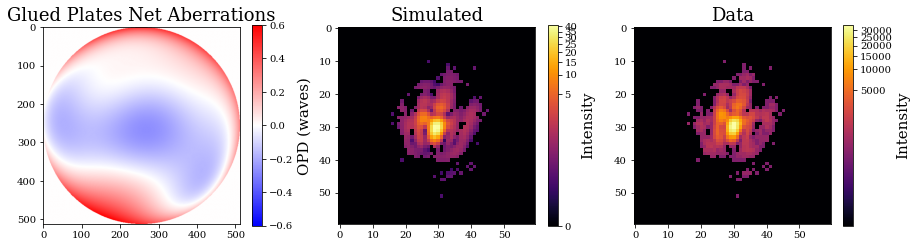

In [56]:
imgs = [jnp.asarray([np.flip(np.load(data_dir+"glued/18_09_2025/18_09_2025_0deg_red_93us_0gain_img_stack_batch_0.npy")) for img_fname in img_fnames]),
        ]


coeffs_list = [pickle.load(open(save_dir +plate_name+ "_red_coeffs_dict.pkl",'rb'))['value'],
                ]

for i, coeffs in enumerate(coeffs_list):

    zern_basis = dlu.zernike_basis(js=zernike_indicies, diameter=aperture_diameter,coordinates=coords)
    plate_errors = dl.layers.BasisOptic(zern_basis, circle*intensity_dist, coeffs, normalise=False)

    opd_basis = plate_errors.eval_basis()
    new_optics_sp180 = optics_sp180.insert_layer(layer=("plate", plate_errors), index=1)
    instrument_sp180 = dl.Telescope(new_optics_sp180, ('source', red_src))

    real_img = imgs[i][0][0]
    psf_center_idx = jnp.unravel_index(jnp.argmax(real_img, axis=None), real_img.shape)
    real_img = real_img[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                        psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
    real_img_mask = jnp.ones(real_img.shape)
    real_img_mask = real_img_mask.at[real_img == 255].set(0)

    plt.figure(figsize=(15,8))
    plt.subplot(2,3,1)
    plt.imshow(opd_basis/red_laser_wl, norm=CenteredNorm(), cmap='bwr')
#     plt.imshow(opd_basis/red_laser_wl)

    plt.title("Glued Plates Net Aberrations")
    plt.colorbar(label="OPD (waves)")

    plt.subplot(2,3,2)
    psf = instrument_sp180.model()
    pnorm = PowerNorm(0.2)
    plt.imshow(psf*real_img_mask, norm=pnorm)
    plt.colorbar(label="Intensity")
    plt.title("Simulated")

    plt.subplot(2,3,3)
    plt.imshow(real_img, norm=PowerNorm(0.2))
    plt.colorbar(label="Intensity")
    plt.title("Data")

    opd_waves = opd_basis/red_laser_wl
    peak_valley = opd_waves.max() - opd_waves.min()
    print("P-V WFE: {}waves".format(peak_valley))



______________________________________________________________________________________________________________________________________________________________________________________________

Post full-cure

In [7]:
f_aberr = "data/spider/retrieval_results/16_10_2025/system_coeffs_dict.pkl"

syst_noll = jnp.arange(4, 15) # only first 14 Zernike modes (excluding piston and tip/tilt) are used to classify syst aberrations
# syst_coeffs = jnp.load(f_aberr)
syst_coeffs = pickle.load(open(f_aberr, "rb"))["value"]
syst_basis = dlu.zernike_basis(js=syst_noll, diameter=aperture_diameter, coordinates=coords)
print("System Coefficients (noll {}): {}".format(syst_noll,syst_coeffs))


System Coefficients (noll [ 4  5  6  7  8  9 10 11 12 13 14]): [-1.54000000e-08 -1.02234354e-23 -1.26000000e-08  9.00000000e-09
  8.60000000e-09 -2.24000000e-08 -3.80000000e-09  2.90000000e-08
 -6.00000000e-10  3.60000000e-09 -1.20000000e-08]


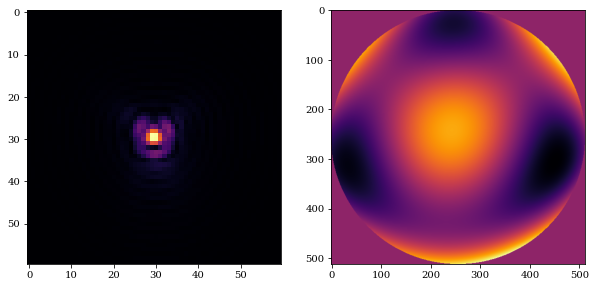

In [8]:
# Re-create base models with new syst aberrations
psf_npix = 60                 # Number of pixels along one dim of the PSF
psf_hlf_sz = int(psf_npix/2)   # half window sz of cropped data
zernike_indicies = jnp.arange(4, 31) 
coeffs = jnp.zeros(zernike_indicies.shape)
basis = dlu.zernike_basis(js=zernike_indicies, coordinates=coords, diameter=aperture_diameter)
optical_systems = []
transmissions = []
for i in range(len(spider_angles)):
    spider = dlu.spider(coords=coords, width=spider_width, angles=[spider_angles[i]])
    transmission = dlu.combine([circle, spider])

    layers = [
        ('SystemAberrations', dl.layers.BasisOptic(basis=syst_basis, coefficients=syst_coeffs, normalise=False)),
        ('intensity', dl.layers.TransmissiveLayer(transmission=intensity_dist, normalise=False)),
        ('spider', TransmissiveLayer(transmission=transmission, normalise=False)),
        ('aperture', dl.layers.BasisOptic(basis=basis, transmission=None, coefficients=coeffs, normalise=False)),
    ]
    optics = dl.AngularOpticalSystem(wf_npixels = wf_npixels, 
                                diameter=wf_diam, 
                                layers=layers, 
                                psf_npixels=psf_npix, 
                                psf_pixel_scale=psf_pixel_scale,
                                oversample=oversample)

    optical_systems.append(optics)
    transmissions.append(transmission)

# Construct Optics
optics_sp270  = optical_systems[0]
optics_sp180 = optical_systems[1]

# Check PSF for aberrated system
layers = [
    ('SystemAberrations', dl.layers.BasisOptic(syst_basis, circle*intensity_dist, syst_coeffs, normalise=False)),
]

optics = dl.AngularOpticalSystem(wf_npixels = wf_npixels, 
                            diameter=wf_diam, 
                            layers=layers, 
                            psf_npixels=psf_npix, 
                            psf_pixel_scale=psf_pixel_scale,
                            oversample=oversample)

psf = optics.propagate_mono(green_laser_wl)
plt.subplot(1,2,1)
plt.imshow(jnp.flip(psf)**0.5)
# plt.xlim([200,250])
# plt.ylim([200,250])
opd = optics.SystemAberrations.eval_basis()
plt.subplot(1,2,2)
plt.imshow(opd)


In [9]:
row_start, col_start = 1910, 2940 # Start coord of window on det where data was taken
row_len, col_len = 100, 100   # window size of recorded data

alpha_cropped = jnp.flip(alpha[row_start:row_start+row_len, col_start:col_start+col_len])
beta_cropped = jnp.flip(beta[row_start:row_start+row_len, col_start:col_start+col_len])
gamma_cropped = jnp.flip(gamma[row_start:row_start+row_len, col_start:col_start+col_len])

# Order in increasing spider angle for each colour separately
img_fnames = [
    # "glued/28_07_2025/28_07_0deg_green_93us_0gain_img_stack_batch_0.npy",
    # "glued/28_07_2025/28_07_90deg_green_120us_0gain_img_stack_batch_0.npy",
    # "glued/26_08_2025/defoc_26_08_2025_0deg_red_80us_0gain_img_stack_batch_0.npy",
    # "glued/26_08_2025/defoc_26_08_2025_90deg_red_80us_0gain_img_stack_batch_0.npy",
    "glued/16_10_2025/16_10_2025_0deg_red_173us_0gain_img_stack_batch_0.npy",
    "glued/16_10_2025/16_10_2025_90deg_red_173us_0gain_img_stack_batch_0.npy"

]

labels = [
    # "0deg_green",
    # "90deg_green",
    "0deg_red",
    "90deg_red",
]
# bckgnd_fnames = [
#     # "glued/28_07_2025/28_07_0deg_green_bckgnd_93us_0gain_img_stack_batch_0.npy",
#     # "glued/28_07_2025/28_07_90deg_green_bckgnd_120us_0gain_img_stack_batch_0.npy",
#     "glued/18_09_2025/18_09_2025_0deg_red_bckgnd_93us_0gain_img_stack_batch_0.npy",
#     "glued/18_09_2025/18_09_2025_90deg_red_bckgnd_93us_0gain_img_stack_batch_0.npy",
# ]

imgs = jnp.asarray([np.flip(np.load(data_dir+img_fname)) for img_fname in img_fnames])
n_frames = 30   #number of frames to perform phase retrieval on
step_sz = int(imgs[0].shape[0]/n_frames) # step size for frames (equally spaced frame grabs)

# bckgnds = jnp.asarray([np.mean(np.flip(np.load(data_dir+bckgnd_fname)),axis=0) for bckgnd_fname in bckgnd_fnames])  # single bck
bckgnds=[]


In [10]:
# Create directory that will hold all subsequent data products
save_dir = "data/glued/18_09_2025/"
plate_name = "glued_fully_cured"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
elif len(os.listdir(save_dir)) != 0:
    print("Warning: Files already exist in root directory. ")
if not os.path.exists(save_dir+"combined/"):
    os.makedirs(save_dir+"combined/")
elif len(os.listdir(save_dir+"combined/")) != 0:
    print("Warning: Files already exist in root directory. ")

In [11]:
frames_i = np.arange(0, imgs.shape[1], step_sz) # indices to sample frame
# frames_i = np.array([0,1])

# instrument_sp180_g = dl.Telescope(optics_sp180, ('source', green_src))
# instrument_sp270_g = dl.Telescope(optics_sp270, ('source', green_src))
instrument_sp180_r = dl.Telescope(optics_sp180, ('source', red_src))
instrument_sp270_r = dl.Telescope(optics_sp270, ('source', red_src))
sim_psfs = [instrument_sp180_r.model(), instrument_sp270_r.model()]

linear_imgs = []
img_masks = []
for frame_n in frames_i:
    data_sp180_r = imgs[0][frame_n,:,:] 
    data_sp270_r = imgs[1][frame_n,:,:]

    data_list = [data_sp180_r, data_sp270_r]
    masks = []
    scaled_data_list = []
    for j in range(len(data_list)):
        data = data_list[j]
        if len(bckgnds) > 0:
            data = data - bckgnds[j]
        m = jnp.ones(data.shape)
        m = m.at[data <= 255].set(0.0)

        # Reverse-model detector response
        data_remapped = 0.0 + ((1.0 - 0.0)/(data.max()-data.min()))*(data - data.min()) #[0,1] otput range
        data = np.power((data_remapped-alpha_cropped)/beta_cropped, (1/gamma_cropped)) 

        # Scale intensity
        current_range = data.max() - data.min()
        new_range = sim_psfs[j].max() - sim_psfs[j].min()
        scaled_data = ( (data - data.min()) * new_range )/current_range + sim_psfs[j].min()

        psf_center_idx = np.unravel_index(np.argmax(scaled_data, axis=None), scaled_data.shape)
        scaled_data = scaled_data[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
        masks.append(m[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                    psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz])
        
        scaled_data_list.append(scaled_data)

    linear_imgs.append(scaled_data_list)
    img_masks.append(masks)

linear_imgs = jnp.asarray(linear_imgs)
img_masks = jnp.asarray(img_masks)


In [12]:
params = [
    "aperture.coefficients",
    "spider.rotation",
    "source.position",
    "source.flux", 
    ]


optimisers = [
            optax.adam(learning_rate=1e-10),
            optax.adam(learning_rate=1e-4),
            optax.adam(learning_rate=1e-9),
            optax.adam(learning_rate=1e6),
              ]

In [13]:
# init w/ 2 plate aberration
ng_dir = "data/non_glued/08_09_2025/"
p1,p2 = pickle.load(open(ng_dir+"plate1_red_coeffs_dict.pkl", 'rb'))['value'], pickle.load(open(ng_dir+"plate2_red_coeffs_dict.pkl", 'rb'))['value']
init_z_coeffs = jnp.zeros(zernike_indicies.shape)
# init_z_coeffs = init_z_coeffs.at[:p1.shape[0]].set(p1+p2) # sum of the 2 plates
init_z_coeffs = init_z_coeffs.at[zernike_indicies == 4].set(633e-9 * 1/2) # initialise with some defocus 
init_z_coeffs

Array([3.165e-07, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00], dtype=float64)

In [14]:
# Create models - one per frame of data
configs = [instrument_sp180_r, instrument_sp270_r] # model configurations to optimise upon
models = []
init_coeffs = True
for i, instrument_model in enumerate(configs):
    # make x copies of the model, one for each frame of data
    if init_coeffs:
        instrument_model = instrument_model.set("aperture.coefficients", init_z_coeffs)
        
    temp_config = [instrument_model]*frames_i.shape[0]
    models.append(temp_config)


In [15]:
# Create optimisation managers - one per spider configuration
OMS = []
for i in range(len(models)):
    om = OptimManager(
        models=models[i],
        data=linear_imgs[:,i,:,:], 
        params=params,
        loss_fn="poisson", # poisson loss for photon counting
        optimisers=optimisers,
        jointly_fit_params=["spider.rotation"], # each config has a unique spider orientation - jointly fit for that over time/frames
    )

    OMS.append(om)

# Create a joint optimisation manager to optimise the system aberrations over both spider configs
optimisation_manager = JointOptimManager(optim_managers=OMS,
                                        jointly_fit_params=["aperture.coefficients"], # coefficients should be same over time over both spider orientations
                                        )

In [ ]:
optimisation_manager.run_optimisation(num_steps=6000)

Loss:   0%|          | 0/6000 [00:00<?, ?it/s]

In [17]:
filenames = [save_dir+plate_name+"_red_0deg_stored_params_dict.pkl", save_dir+plate_name+"_red_90deg_stored_params_dict.pkl"]
optimisation_manager.save_stored_params(filenames=filenames)

Stored parameters saved to data/glued/18_09_2025/glued_fully_cured_red_0deg_stored_params_dict.pkl
Stored parameters saved to data/glued/18_09_2025/glued_fully_cured_red_90deg_stored_params_dict.pkl


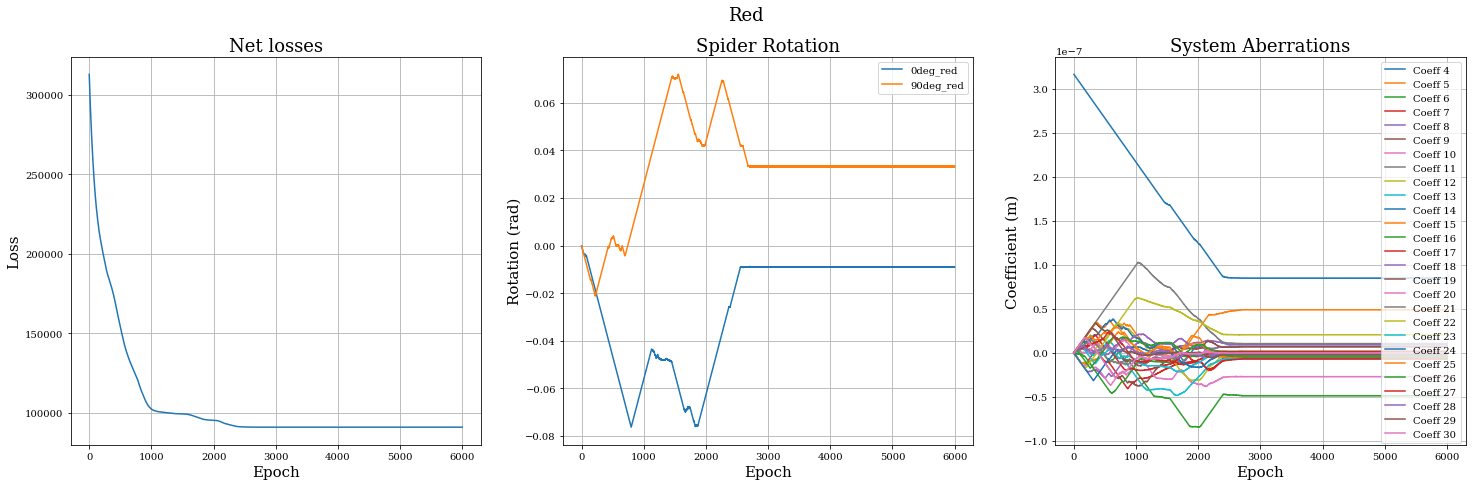

In [18]:
stored_params_dict= pickle.load(open(filenames[0], 'rb'))
plt.figure(figsize=(25,7))
plt.suptitle("Red")
plt.subplot(1,3,1)
plt.title("Net losses")
plt.plot(stored_params_dict["net loss"])
plt.xlabel("Epoch")
plt.grid()
plt.ylabel("Loss")

plt.subplot(1,3,3)
plt.title("System Aberrations")
coeffs_arr = np.asarray(stored_params_dict["aperture.coefficients"])[:,0,:]
for l in range(coeffs_arr.shape[-1]):
    label = "Coeff " + str(zernike_indicies[l])
    plt.plot(coeffs_arr[:,l], label=label)
plt.legend()
plt.ylabel("Coefficient (m)")
plt.xlabel("Epoch")
plt.grid()

plt.subplot(1,3,2)
plt.title("Spider Rotation")
for i, filename in enumerate(filenames):
    stored_params_dict = pickle.load(open(filename, 'rb'))
    plt.plot(np.asarray(stored_params_dict["spider.rotation"])[:,0,0], label=labels[i])
plt.ylabel("Rotation (rad)")
plt.xlabel("Epoch")
plt.legend()
plt.grid()

In [19]:
config_stored_params = [pickle.load(open(filenames[0], 'rb')),
                          pickle.load(open(filenames[1], 'rb'))]
config_models = optimisation_manager.models
config_labels = ["sp180", "sp270"]


In [20]:
for frame_n in range(frames_i.shape[0]):
    plt.figure(figsize=(16,18))
    plt.subplot(4,3,1)
    for i, stored_params_dict in enumerate(config_stored_params):
        pos = np.asarray(stored_params_dict["source.position"])
        Positions_sp180 = pos[:,frame_n,0]
        Positions_sp270 = pos[:,frame_n,1]
        plt.plot(Positions_sp180, label="Position X - {}".format(config_labels[i]))
        plt.plot(Positions_sp270, label="Position Y - {}".format(config_labels[i]))
    plt.title("Source Position")
    plt.legend()

    plt.subplot(4,3,2)
    coeffs_arr = np.asarray(stored_params_dict["aperture.coefficients"])[:,frame_n,:]
    for l in range(coeffs_arr.shape[-1]):
        label = "Coeff " + str(zernike_indicies[l])
        plt.plot(coeffs_arr[:,l], label=label)
    plt.legend()
    plt.title("Plate Zern Coefficients")

    plt.subplot(4,3,3)
    for i, stored_params_dict in enumerate(config_stored_params):
        fluxes_arr = np.asarray(stored_params_dict["source.flux"])
        plt.plot(fluxes_arr[:,frame_n,:], label="config{}".format(config_labels[i]))
    plt.title("Flux")
    plt.legend()

    plt.subplot(4,3,4)
    for i, stored_params_dict in enumerate(config_stored_params):
        spider_rot_arr = np.asarray(stored_params_dict["spider.rotation"])
        plt.plot(spider_rot_arr[:,frame_n,:], label="Spider {}".format(config_labels[i])) # any of the models here will yield same result for jointly fit
    plt.ylabel("Rotation (rad)")
    plt.xlabel("Epoch")

    it = 5
    spider_configs=[config_models[0][frame_n], config_models[1][frame_n]]
    for k, config in enumerate(spider_configs):
        plt.subplot(4,3,it)
        # print(config.source.spectrum.wavelengths)
        opd = config.aperture.eval_basis()
        trans = config.spider.transmission
        plt.imshow(opd*trans, cmap='viridis')
        plt.title('Retrieved Aberrations - config {}'.format(k))
        plt.colorbar()
        it+=1

    for k, config in enumerate(spider_configs):
        scaled_data = optimisation_manager.OptimManagers[k].data[frame_n] 
        plt.subplot(4,3,it)
        norm_psf = PowerNorm(0.2, vmax=scaled_data.max(), vmin=scaled_data.min())
        plt.imshow(scaled_data, norm=norm_psf)
        plt.colorbar()
        plt.ylabel("Config {}".format(k))
        plt.title('Data')
        it+=1

        plt.subplot(4,3,it)
        model_psf = config.model()
        # current_range = model_psf.max() - model_psf.min()
        # new_range = scaled_data.max() - scaled_data.min()
        # model_psf = ( (model_psf - model_psf.min()) * new_range )/current_range + scaled_data.min()
        norm_psf = PowerNorm(0.2, vmax=model_psf.max(), vmin=model_psf.min())
        plt.imshow(model_psf*img_masks[frame_n][k], norm=norm_psf)
        plt.title('Model')
        plt.colorbar()
        it+=1

        plt.subplot(4,3,it)
        resid = scaled_data - model_psf
        plt.imshow(resid, cmap='bwr', vmax = np.abs(resid).max(), vmin = -np.abs(resid).max())
        plt.colorbar()
        plt.title('Residuals')
        it+=1

    # plt.tight_layout()
    # break
    plt.savefig(save_dir+"combined/"+plate_name+"_red_frame_" + str(frame_n) + ".png")
    plt.close()

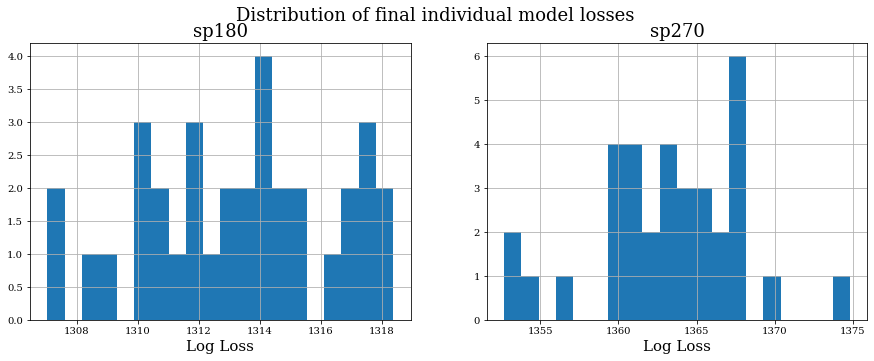

In [21]:
plt.figure(figsize=(15,5))
plt.suptitle("Distribution of final individual model losses")
it =1
for i, stored_params_dict in enumerate(config_stored_params):
    log_losses = np.asarray(stored_params_dict["final losses"]).flatten()
    plt.subplot(1,2,it)
    plt.title("{}".format(config_labels[i]))
    plt.hist(log_losses, bins=20)
    plt.xlabel("Log Loss")
    plt.grid()
    it +=1

In [22]:
# calc CRLB and save coeffs + associated uncertainties  
# called AFTER optimisation (i.e. evaluated at MLE)
CRLB = optimisation_manager.calc_CRLB(param="aperture.coefficients")
CRLB_max = [crlb.max(axis=0) for crlb in CRLB] # take the maximum uncertainty
CRLB_max = np.nanmax(np.asarray(CRLB_max),axis=0)
coeffs = optimisation_manager.OptimManagers[0].models[0].aperture.coefficients # any config for any frame model

ddict = {}
ddict['value'] = coeffs
ddict['stdev']=CRLB_max
ddict['SEM']=CRLB_max/np.sqrt(frames_i.shape[0])
print("Calculating SEM over {} frames".format(frames_i.shape[0]))
pickle.dump(ddict, open(save_dir+plate_name+"_red_coeffs_dict.pkl", 'wb'))

Calculating SEM over 34 frames


/tmp/ipykernel_1020947/3362112381.py:5: RuntimeWarning: All-NaN slice encountered
  CRLB_max = np.nanmax(np.asarray(CRLB_max),axis=0)


red RMS WFE: 0.184lambda
Mean RMS WFE: 0.184lambda


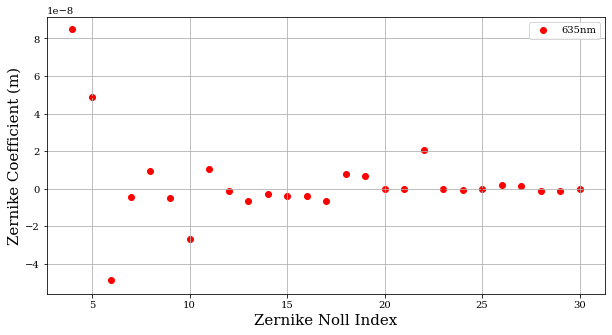

In [23]:
# plot this info
stored_coeffs = pickle.load(open(save_dir +plate_name+ "_red_coeffs_dict.pkl",'rb'))
mean, stdev = stored_coeffs["value"], stored_coeffs["SEM"]

plt.figure(figsize=(10,5))
wf_errs = []
labels = ['red']
stdevs = [stdev]
for i,coeffs in enumerate([mean]):

    if 'red' in labels[i]:
        wl = red_laser_wl
        colour = 'r'
    elif 'green' in labels[i]:
        wl = green_laser_wl
        colour = 'g'
    else:
        ValueError("Unknown Wavelength")

    plt.scatter(zernike_indicies, coeffs, label=str(round(wl*1e9))+"nm", c=colour)
    plt.errorbar(zernike_indicies, coeffs, yerr=stdevs[i],ecolor=colour, capsize=2,linestyle='')
    RMS_wf_err = ((coeffs**2).sum())**0.5

    print("{} RMS WFE: {:.3f}lambda".format(labels[i], RMS_wf_err/wl))
    wf_errs.append(RMS_wf_err/wl) 

plt.xlabel("Zernike Noll Index")
plt.ylabel("Zernike Coefficient (m)")
plt.grid()
plt.legend()

print("Mean RMS WFE: {:.3f}lambda".format(np.mean(wf_errs)))

Compare to single plates

In [67]:
config_models[0][10].aperture.coefficients

Array([ 1.40000000e-09,  2.00000000e-09,  8.80000000e-09,  8.80000000e-09,
       -5.70108388e-23,  1.00000000e-09,  3.00000000e-09, -5.20000000e-09,
        5.40000000e-09, -3.60000000e-09, -3.00000000e-09,  4.20000000e-09,
       -3.20000000e-09, -5.20000000e-09,  2.00000000e-10,  5.40000000e-09,
        2.80000000e-09], dtype=float64)

In [66]:
config_models[0][frame_n].aperture.coefficients

Array([ 1.40000000e-09,  2.00000000e-09,  8.80000000e-09,  8.80000000e-09,
       -5.70108388e-23,  1.00000000e-09,  3.00000000e-09, -5.20000000e-09,
        5.40000000e-09, -3.60000000e-09, -3.00000000e-09,  4.20000000e-09,
       -3.20000000e-09, -5.20000000e-09,  2.00000000e-10,  5.40000000e-09,
        2.80000000e-09], dtype=float64)

In [65]:
mean_coeffs

Array([ 1.40000000e-09,  2.00000000e-09,  8.80000000e-09,  8.80000000e-09,
       -5.70108388e-23,  1.00000000e-09,  3.00000000e-09, -5.20000000e-09,
        5.40000000e-09, -3.60000000e-09, -3.00000000e-09,  4.20000000e-09,
       -3.20000000e-09, -5.20000000e-09,  2.00000000e-10,  5.40000000e-09,
        2.80000000e-09], dtype=float64)

	 4 	 | 6.2e-09±4.4e-09
	 5 	 | -2.4e-09±4.7e-09
	 6 	 | -7.8e-09±4.6e-09
	 7 	 | 1.1e-08±6e-09
	 8 	 | -4.2e-09±7.9e-09
	 9 	 | -1.8e-09±6.4e-09
	 10 	 | 8e-10±5.4e-09
	 11 	 | -6e-10±4.3e-09
	 12 	 | 6.6e-09±4.8e-09
	 13 	 | -8e-10±3.4e-09
	 14 	 | -1.6e-09±5e-09
	 15 	 | 1.8e-09±4.4e-09
	 16 	 | -4.8e-09±4.7e-09
	 17 	 | -3.4e-09±3.5e-09
	 18 	 | -1.8e-09±3.4e-09
	 19 	 | 4.8e-09±5e-09
	 20 	 | 2.4e-09±3.8e-09
	 4 	 | 1.4e-09±1.7e-08
	 5 	 | 2e-09±2.3e-08
	 6 	 | 8.8e-09±9.8e-09
	 7 	 | 8.8e-09±9.5e-09
	 8 	 | -5.7e-23±1.2e-08
	 9 	 | 1e-09±2.4e-08
	 10 	 | 3e-09±7.8e-09
	 11 	 | -5.2e-09±1.7e-08
	 12 	 | 5.4e-09±8.2e-09
	 13 	 | -3.6e-09±9.7e-09
	 14 	 | -3e-09±8.5e-09
	 15 	 | 4.2e-09±1.1e-08
	 16 	 | -3.2e-09±2e-08
	 17 	 | -5.2e-09±9.2e-09
	 18 	 | 2e-10±6.3e-09
	 19 	 | 5.4e-09±1.4e-08
	 20 	 | 2.8e-09±1.5e-08


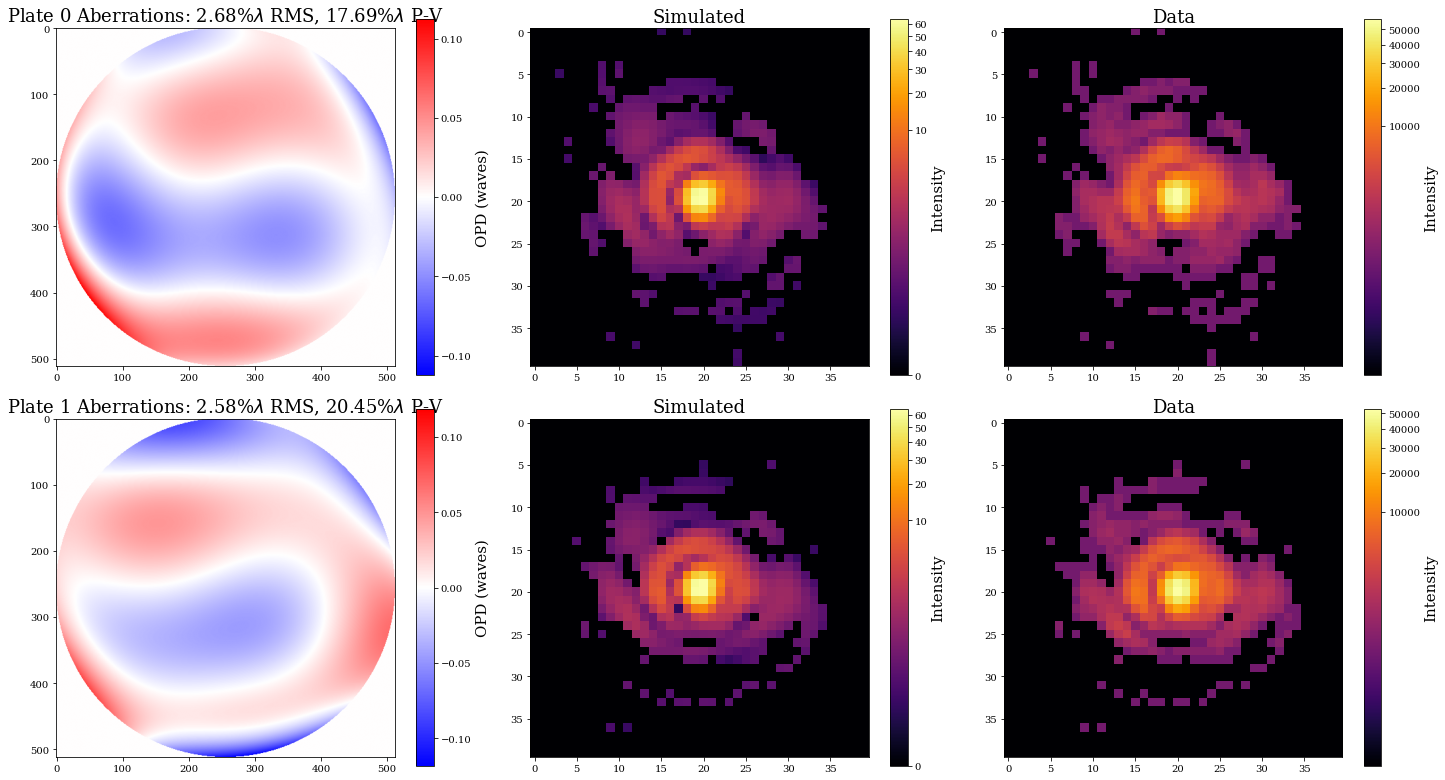

In [71]:
# separate plates 
# Pick single orientation + wl to show this (position+spider rotation assumed unchanged here - looking for general structure)

img_fnames = [ # 1 per plate. starphire 1 followed by 2
    "non_glued/12_01_2026/12_01_2026_plate#3_0deg_red_173us_0gain_Xoff3340_Yoff1840_img_stack_batch_0.npy",
    "non_glued/12_01_2026/12_01_2026_plate#4_0deg_red_173us_0gain_Xoff3340_Yoff1840_img_stack_batch_0.npy",
] 
imgs = jnp.asarray([np.flip(np.load(data_dir+img_fname)) for img_fname in img_fnames])

coeffs_dir = [
            "data/non_glued/12_01_2026/plate1_red_coeffs_dict.pkl", 
            "data/non_glued/12_01_2026/plate2_red_coeffs_dict.pkl",
]

plt.figure(figsize=(20,11))
subplt_it = 1
bases=[]
for i, dir in enumerate(coeffs_dir):
    # coeffs = np.load(dir)
    mean_coeffs = pickle.load(open(dir, 'rb'))['value']
    stdev = pickle.load(open(dir, 'rb'))['stdev'] # CRLB
    for j, c in enumerate(mean_coeffs):
        print("\t {} \t | {:.2g}±{:.2g}".format(zernike_indicies[j], c, stdev[j]))

    zern_basis = dlu.zernike_basis(js=jnp.arange(4,mean_coeffs.shape[0]+4), diameter=aperture_diameter,coordinates=coords)
    plate_errors = dl.layers.BasisOptic(zern_basis, circle*intensity_dist, mean_coeffs, normalise=False)

    opd_basis = plate_errors.eval_basis()
    # new_optics_sp180 = optics_sp180.insert_layer(layer=("plate", plate_errors), index=1)
    # instrument_sp180 = dl.Telescope(new_optics_sp180, ('source', red_src))
    instrument_sp180 = dl.Telescope(optics_sp180.set("aperture.coefficients", mean_coeffs.flatten()), ('source', red_src))

    real_img = imgs[i][5]
    psf_center_idx = jnp.unravel_index(jnp.argmax(real_img, axis=None), real_img.shape)
    real_img = real_img[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                        psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
    real_img_mask = jnp.ones(real_img.shape)
    real_img_mask = real_img_mask.at[real_img == 255].set(0)

    plt.subplot(2,3,subplt_it)
    cnorm = CenteredNorm(vcenter=0)
    plt.imshow(opd_basis/red_laser_wl, norm=cnorm, cmap='bwr')
    peak_valley = opd_basis.max() - opd_basis.min()
    plt.title("Plate {} Aberrations: {:.2f}%$\lambda$ RMS, {:.2f}%$\lambda$ P-V".format(i, np.std(opd_basis)/red_laser_wl*100, peak_valley/red_laser_wl*100))
    plt.colorbar(label="OPD (waves)")
    subplt_it += 1
    plt.subplot(2,3,subplt_it)
    psf = instrument_sp180.model()
    plt.imshow(psf*real_img_mask, norm=PowerNorm(0.2))
    plt.colorbar(label="Intensity")
    plt.title("Simulated")
    subplt_it += 1
    plt.subplot(2,3,subplt_it)
    plt.imshow(real_img, norm=PowerNorm(0.2))
    plt.colorbar(label="Intensity")
    plt.title("Data")
    subplt_it += 1

    bases.append(plate_errors)

#

plt.tight_layout()

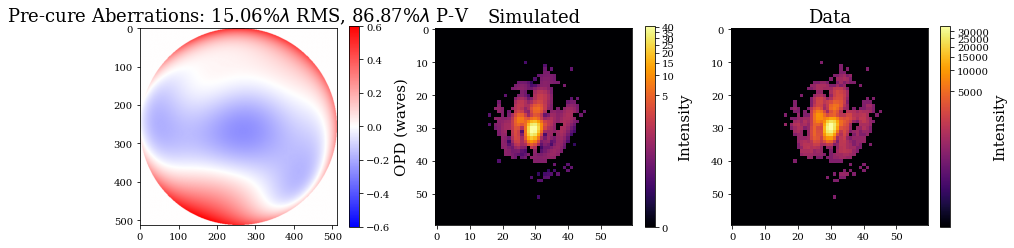

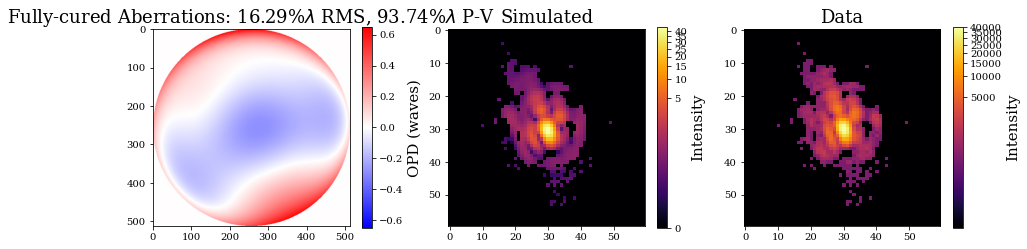

In [38]:
# pre-cure only
imgs = [jnp.asarray([np.flip(np.load(data_dir+"glued/18_09_2025/18_09_2025_0deg_red_93us_0gain_img_stack_batch_0.npy")) for img_fname in img_fnames]),
        ]


coeffs_list = [pickle.load(open(save_dir +"glued"+ "_red_coeffs_dict.pkl",'rb'))['value'],
                ]

for i, coeffs in enumerate(coeffs_list):

    zern_basis = dlu.zernike_basis(js=zernike_indicies, diameter=aperture_diameter,coordinates=coords)
    plate_errors = dl.layers.BasisOptic(zern_basis, circle*intensity_dist, coeffs, normalise=False)

    opd_basis = plate_errors.eval_basis()
    new_optics_sp180 = optics_sp180.insert_layer(layer=("plate", plate_errors), index=1)
    instrument_sp180 = dl.Telescope(new_optics_sp180, ('source', red_src))

    real_img = imgs[i][0][0]
    psf_center_idx = jnp.unravel_index(jnp.argmax(real_img, axis=None), real_img.shape)
    real_img = real_img[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                        psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
    real_img_mask = jnp.ones(real_img.shape)
    real_img_mask = real_img_mask.at[real_img == 255].set(0)

    plt.figure(figsize=(15,8))
    plt.subplot(2,3,1)
    plt.imshow(opd_basis/red_laser_wl, norm=CenteredNorm(), cmap='bwr')
    peak_valley = opd_basis.max() - opd_basis.min()
    plt.title("Pre-cure Aberrations: {:.2f}%$\lambda$ RMS, {:.2f}%$\lambda$ P-V".format(np.std(opd_basis)/red_laser_wl*100, peak_valley/red_laser_wl*100))
    plt.colorbar(label="OPD (waves)")

    plt.subplot(2,3,2)
    psf = instrument_sp180.model()
    pnorm = PowerNorm(0.2)
    plt.imshow(psf*real_img_mask, norm=pnorm)
    plt.colorbar(label="Intensity")
    plt.title("Simulated")

    plt.subplot(2,3,3)
    plt.imshow(real_img, norm=PowerNorm(0.2))
    plt.colorbar(label="Intensity")
    plt.title("Data")


# fully-cured
imgs = [jnp.asarray([np.flip(np.load(data_dir+"glued/16_10_2025/16_10_2025_0deg_red_173us_0gain_img_stack_batch_0.npy")) for img_fname in img_fnames]),
        ]


coeffs_list = [pickle.load(open(save_dir +"glued_fully_cured"+ "_red_coeffs_dict.pkl",'rb'))['value'],
                ]

for i, coeffs in enumerate(coeffs_list):

    zern_basis = dlu.zernike_basis(js=zernike_indicies, diameter=aperture_diameter,coordinates=coords)
    plate_errors = dl.layers.BasisOptic(zern_basis, circle*intensity_dist, coeffs, normalise=False)

    opd_basis = plate_errors.eval_basis()
    new_optics_sp180 = optics_sp180.insert_layer(layer=("plate", plate_errors), index=1)
    instrument_sp180 = dl.Telescope(new_optics_sp180, ('source', red_src))

    real_img = imgs[i][0][0]
    psf_center_idx = jnp.unravel_index(jnp.argmax(real_img, axis=None), real_img.shape)
    real_img = real_img[psf_center_idx[0]-psf_hlf_sz:psf_center_idx[0]+psf_hlf_sz,
                                        psf_center_idx[1]-psf_hlf_sz:psf_center_idx[1]+psf_hlf_sz]
    real_img_mask = jnp.ones(real_img.shape)
    real_img_mask = real_img_mask.at[real_img == 255].set(0)

    plt.figure(figsize=(15,8))
    plt.subplot(2,3,1)
    plt.imshow(opd_basis/red_laser_wl, norm=CenteredNorm(), cmap='bwr')
    peak_valley = opd_basis.max() - opd_basis.min()
    plt.title("Fully-cured Aberrations: {:.2f}%$\lambda$ RMS, {:.2f}%$\lambda$ P-V".format(np.std(opd_basis)/red_laser_wl*100, peak_valley/red_laser_wl*100))

    plt.colorbar(label="OPD (waves)")

    plt.subplot(2,3,2)
    psf = instrument_sp180.model()
    pnorm = PowerNorm(0.2)
    plt.imshow(psf*real_img_mask, norm=pnorm)
    plt.colorbar(label="Intensity")
    plt.title("Simulated")

    plt.subplot(2,3,3)
    plt.imshow(real_img, norm=PowerNorm(0.2))
    plt.colorbar(label="Intensity")
    plt.title("Data")

